In [2]:
import pandas as pd

# Load the city-level daily air quality dataset
df = pd.read_csv(r"D:\Downloads\archive\city_day.csv")

# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display first 5 records
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (29531, 16)

Column Names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

First 5 Rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# STEP 2: RAW DATA AUDIT

print("===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percent.round(2)
})

print(missing_report)

print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n===== BASIC STATISTICS =====")
display(df.describe(include="all").T)

===== DATA TYPES =====
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

===== MISSING VALUES =====
            Missing_Count  Missing_Percentage
City                    0                0.00
Date                    0                0.00
PM2.5                4598               15.57
PM10                11140               37.72
NO                   3582               12.13
NO2                  3585               12.14
NOx                  4185               14.17
NH3                 10328               34.97
CO                   2059                6.97
SO2                  3854               13.05
O3                   4022               13.62
Benzene              5623      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-06-26,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86


In [4]:
# STEP 3: TARGET VARIABLE AUDIT

print("===== AQI BUCKET DISTRIBUTION =====")

target_counts = df["AQI_Bucket"].value_counts(dropna=False)

target_percent = (
    df["AQI_Bucket"]
    .value_counts(normalize=True, dropna=False) * 100
).round(2)

target_report = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

display(target_report)

print("\n===== UNIQUE TARGET VALUES =====")
print(df["AQI_Bucket"].unique())

===== AQI BUCKET DISTRIBUTION =====


,Count,Percentage
AQI_Bucket,,
Moderate,8829,29.90
Satisfactory,8224,27.85
NaN,4681,15.85
Poor,2781,9.42
Very Poor,2337,7.91
Good,1341,4.54
Severe,1338,4.53



===== UNIQUE TARGET VALUES =====
[nan 'Poor' 'Very Poor' 'Severe' 'Moderate' 'Satisfactory' 'Good']


In [5]:
# STEP 4: CHECK TEMPORAL STRUCTURE FOR NEXT-DAY FORECASTING

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by city and date
df_sorted = df.sort_values(["City", "Date"]).copy()

print("===== DATE RANGE =====")
print("First date:", df_sorted["Date"].min())
print("Last date:", df_sorted["Date"].max())

print("\n===== NUMBER OF CITIES =====")
print("Number of cities:", df_sorted["City"].nunique())

print("\n===== CITIES =====")
print(df_sorted["City"].unique())

# Create a temporary next-day target
df_sorted["Next_Day_AQI_Bucket"] = (
    df_sorted.groupby("City")["AQI_Bucket"].shift(-1)
)

print("\n===== NEXT-DAY TARGET AVAILABILITY =====")

next_day_counts = df_sorted["Next_Day_AQI_Bucket"].value_counts(dropna=False)

next_day_percent = (
    df_sorted["Next_Day_AQI_Bucket"]
    .value_counts(normalize=True, dropna=False) * 100
).round(2)

next_day_report = pd.DataFrame({
    "Count": next_day_counts,
    "Percentage": next_day_percent
})

display(next_day_report)

===== DATE RANGE =====
First date: 2015-01-01 00:00:00
Last date: 2020-07-01 00:00:00

===== NUMBER OF CITIES =====
Number of cities: 26

===== CITIES =====
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']

===== NEXT-DAY TARGET AVAILABILITY =====


,Count,Percentage
Next_Day_AQI_Bucket,,
Moderate,8829,29.90
Satisfactory,8224,27.85
NaN,4682,15.85
Poor,2781,9.42
Very Poor,2337,7.91
Good,1341,4.54
Severe,1337,4.53


In [6]:
# STEP 5: VERIFY CONSECUTIVE DAILY OBSERVATIONS

# Work with the sorted dataframe from Step 4
date_check = df_sorted[["City", "Date"]].copy()

# Calculate the number of days between consecutive observations
date_check["Days_Between"] = (
    date_check.groupby("City")["Date"].diff().dt.days
)

print("===== DATE GAP ANALYSIS =====")

print("\nNumber of observations with a 1-day gap:")
print((date_check["Days_Between"] == 1).sum())

print("\nNumber of observations with gaps greater than 1 day:")
print((date_check["Days_Between"] > 1).sum())

print("\nNumber of observations with missing/undefined previous date:")
print(date_check["Days_Between"].isna().sum())

print("\n===== GAP DISTRIBUTION =====")
display(
    date_check["Days_Between"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\n===== LARGEST DATE GAPS =====")
display(
    date_check.sort_values("Days_Between", ascending=False).head(20)
)

===== DATE GAP ANALYSIS =====

Number of observations with a 1-day gap:
29505

Number of observations with gaps greater than 1 day:
0

Number of observations with missing/undefined previous date:
26

===== GAP DISTRIBUTION =====


Days_Between
1.0    29505
Name: count, dtype: int64


===== LARGEST DATE GAPS =====


,City,Date,Days_Between
29530,Visakhapatnam,2020-07-01,1.0
29514,Visakhapatnam,2020-06-15,1.0
29513,Visakhapatnam,2020-06-14,1.0
29512,Visakhapatnam,2020-06-13,1.0
29511,Visakhapatnam,2020-06-12,1.0
29510,Visakhapatnam,2020-06-11,1.0
29509,Visakhapatnam,2020-06-10,1.0
29508,Visakhapatnam,2020-06-09,1.0
29507,Visakhapatnam,2020-06-08,1.0
29506,Visakhapatnam,2020-06-07,1.0


Create the forecasting target


In [7]:
# STEP 6: CREATE NEXT-DAY FORECASTING TARGET

# Start from the chronologically sorted data
model_df = df_sorted.copy()

# Create tomorrow's AQI category for each city
model_df["Target_Next_Day_AQI"] = (
    model_df.groupby("City")["AQI_Bucket"].shift(-1)
)

print("===== FORECASTING DATASET =====")

print("Original rows:", len(model_df))

print(
    "Rows with available next-day target:",
    model_df["Target_Next_Day_AQI"].notna().sum()
)

print(
    "Rows without next-day target:",
    model_df["Target_Next_Day_AQI"].isna().sum()
)

print("\n===== NEXT-DAY TARGET DISTRIBUTION =====")

target_counts = model_df["Target_Next_Day_AQI"].value_counts()

target_percent = (
    model_df["Target_Next_Day_AQI"]
    .value_counts(normalize=True) * 100
).round(2)

forecast_target_report = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

display(forecast_target_report)

print("\n===== SAMPLE FORECASTING RECORDS =====")

display(
    model_df[
        [
            "City",
            "Date",
            "AQI",
            "AQI_Bucket",
            "Target_Next_Day_AQI"
        ]
    ].head(10)
)

===== FORECASTING DATASET =====
Original rows: 29531
Rows with available next-day target: 24849
Rows without next-day target: 4682

===== NEXT-DAY TARGET DISTRIBUTION =====


,Count,Percentage
Target_Next_Day_AQI,,
Moderate,8829,35.53
Satisfactory,8224,33.10
Poor,2781,11.19
Very Poor,2337,9.40
Good,1341,5.40
Severe,1337,5.38



===== SAMPLE FORECASTING RECORDS =====


,City,Date,AQI,AQI_Bucket,Target_Next_Day_AQI
0,Ahmedabad,2015-01-01,NaN,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN


Inspect usable forecasting records

In [8]:
# STEP 7: INSPECT USABLE FORECASTING RECORDS

# Keep only rows where tomorrow's AQI category is known
usable_df = model_df[model_df["Target_Next_Day_AQI"].notna()].copy()

print("===== USABLE FORECASTING DATA =====")
print("Rows:", usable_df.shape[0])
print("Columns:", usable_df.shape[1])

print("\n===== FIRST 10 USABLE RECORDS =====")

display(
    usable_df[
        [
            "City",
            "Date",
            "PM2.5",
            "PM10",
            "NO",
            "NO2",
            "NOx",
            "NH3",
            "CO",
            "SO2",
            "O3",
            "Benzene",
            "Toluene",
            "Xylene",
            "AQI",
            "AQI_Bucket",
            "Target_Next_Day_AQI"
        ]
    ].head(10)
)

print("\n===== LAST 10 USABLE RECORDS =====")

display(
    usable_df[
        [
            "City",
            "Date",
            "AQI_Bucket",
            "Target_Next_Day_AQI"
        ]
    ].tail(10)
)

===== USABLE FORECASTING DATA =====
Rows: 24849
Columns: 18

===== FIRST 10 USABLE RECORDS =====


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Target_Next_Day_AQI
27,Ahmedabad,2015-01-28,73.24,NaN,5.72,21.11,25.84,NaN,5.72,36.52,62.42,0.03,0.01,1.41,NaN,NaN,Poor
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,Very Poor
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,Severe
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,Severe
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,Severe
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,Severe
33,Ahmedabad,2015-02-03,139.70,NaN,30.61,28.40,56.73,NaN,30.61,33.79,73.60,0.17,0.03,11.87,660.0,Severe,Poor
34,Ahmedabad,2015-02-04,80.65,NaN,2.37,22.83,24.00,NaN,2.37,25.73,47.30,0.00,0.00,0.00,294.0,Poor,Moderate
35,Ahmedabad,2015-02-05,58.36,NaN,2.60,21.39,23.31,NaN,2.60,32.66,53.54,0.00,0.00,0.00,149.0,Moderate,Moderate
36,Ahmedabad,2015-02-06,79.29,NaN,1.16,26.94,26.83,NaN,1.16,67.41,59.30,0.00,0.00,0.00,190.0,Moderate,Poor



===== LAST 10 USABLE RECORDS =====


,City,Date,AQI_Bucket,Target_Next_Day_AQI
29520,Visakhapatnam,2020-06-21,Satisfactory,Satisfactory
29521,Visakhapatnam,2020-06-22,Satisfactory,Satisfactory
29522,Visakhapatnam,2020-06-23,Satisfactory,Satisfactory
29523,Visakhapatnam,2020-06-24,Satisfactory,Satisfactory
29524,Visakhapatnam,2020-06-25,Satisfactory,Good
29525,Visakhapatnam,2020-06-26,Good,Good
29526,Visakhapatnam,2020-06-27,Good,Satisfactory
29527,Visakhapatnam,2020-06-28,Satisfactory,Satisfactory
29528,Visakhapatnam,2020-06-29,Satisfactory,Satisfactory
29529,Visakhapatnam,2020-06-30,Satisfactory,Good


Missing-value analysis on our actual modelling data


In [9]:
# STEP 8: MISSING-VALUE ANALYSIS FOR MODELLING DATA

print("===== MISSING VALUES IN USABLE FORECASTING DATA =====")

missing_count = usable_df.isnull().sum()
missing_percentage = (missing_count / len(usable_df)) * 100

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage.round(2)
})

# Show only columns that contain missing values
missing_report = missing_report[
    missing_report["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

display(missing_report)

print("\n===== COMPLETE-CASE INFORMATION =====")

complete_rows = usable_df.dropna().shape[0]

print("Rows with no missing values:", complete_rows)
print("Rows with at least one missing value:", len(usable_df) - complete_rows)

print(
    "Percentage of rows with at least one missing value:",
    round((len(usable_df) - complete_rows) / len(usable_df) * 100, 2),
    "%"
)

===== MISSING VALUES IN USABLE FORECASTING DATA =====


,Missing_Count,Missing_Percentage
Xylene,15358,61.81
PM10,7060,28.41
NH3,6498,26.15
Toluene,5799,23.34
Benzene,3504,14.10
NOx,1824,7.34
O3,768,3.09
PM2.5,645,2.60
SO2,563,2.27
AQI,506,2.04



===== COMPLETE-CASE INFORMATION =====
Rows with no missing values: 6158
Rows with at least one missing value: 18691
Percentage of rows with at least one missing value: 75.22 %


Missingness by city

In [10]:
# STEP 9: ANALYZE MISSINGNESS BY CITY

pollutant_columns = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene", "AQI"
]

# Calculate missing percentage for each pollutant within each city
city_missing = (
    usable_df
    .groupby("City")[pollutant_columns]
    .apply(lambda x: x.isnull().mean() * 100)
)

print("===== MISSINGNESS BY CITY (%) =====")

display(city_missing.round(2))

print("\n===== AVERAGE MISSINGNESS BY CITY =====")

city_missing_summary = (
    city_missing.mean(axis=1)
    .sort_values(ascending=False)
    .to_frame("Average_Missing_Percentage")
)

display(city_missing_summary.round(2))

print("\n===== HIGHEST-MISSING FEATURES =====")

feature_missing_average = city_missing.mean(axis=0).sort_values(
    ascending=False
)

display(
    feature_missing_average
    .round(2)
    .to_frame("Average_Missing_Percentage")
)

===== MISSINGNESS BY CITY (%) =====


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
City,,,,,,,,,,,,,
Ahmedabad,0.15,70.24,0.52,0.52,0.00,100.00,0.52,2.92,6.22,2.32,2.32,2.40,2.70
Aizawl,1.80,0.90,0.00,0.00,0.00,0.00,0.00,0.00,7.21,12.61,12.61,100.00,1.80
Amaravati,0.48,0.00,0.00,0.00,0.00,0.00,4.40,0.83,0.00,2.26,2.26,21.17,5.11
Amritsar,6.75,1.69,3.73,0.00,20.96,0.18,3.20,10.83,6.48,13.06,14.48,14.65,2.75
Bengaluru,2.88,14.45,0.05,0.05,0.16,9.90,0.52,0.05,6.65,12.09,4.45,100.00,0.47
Bhopal,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.00,100.00,0.72
Brajrajnagar,2.95,1.26,10.94,10.10,3.23,7.85,0.28,5.47,6.59,2.24,100.00,100.00,5.75
Chandigarh,4.35,0.00,1.34,1.34,1.34,3.34,0.00,0.00,0.00,0.00,0.00,0.00,1.67
Chennai,0.00,84.02,0.00,0.00,0.00,22.51,0.05,0.00,0.64,10.67,9.18,100.00,0.64



===== AVERAGE MISSINGNESS BY CITY =====


,Average_Missing_Percentage
City,
Jorapokhar,39.46
Gurugram,25.19
Thiruvananthapuram,23.95
Bhopal,23.13
Lucknow,21.11
Mumbai,20.06
Brajrajnagar,19.74
Talcher,18.86
Chennai,17.52



===== HIGHEST-MISSING FEATURES =====


,Average_Missing_Percentage
Xylene,66.31
Toluene,29.52
Benzene,19.25
NH3,19.24
PM10,16.55
NOx,6.88
O3,6.00
PM2.5,3.15
NO2,2.88
AQI,2.42


Quantify the Xylene problem

In [11]:
# STEP 10: JUSTIFY HIGH-MISSINGNESS FEATURE REMOVAL

feature_missing = (
    usable_df[pollutant_columns]
    .isnull()
    .mean() * 100
)

xylene_city_missing = (
    usable_df.groupby("City")["Xylene"]
    .apply(lambda x: x.isnull().mean() * 100)
)

print("===== OVERALL Xylene MISSINGNESS =====")
print(f"Xylene missing: {feature_missing['Xylene']:.2f}%")

print("\n===== CITY-LEVEL Xylene MISSINGNESS =====")
print(
    f"Cities with 100% Xylene missing: "
    f"{(xylene_city_missing == 100).sum()}"
)

print(
    f"Cities with more than 50% Xylene missing: "
    f"{(xylene_city_missing > 50).sum()}"
)

print(
    f"Cities with Xylene available for at least some records: "
    f"{(xylene_city_missing < 100).sum()}"
)

print("\n===== OTHER FEATURES ABOVE 20% MISSINGNESS =====")

high_missing = feature_missing[feature_missing > 20].sort_values(
    ascending=False
)

display(
    high_missing.to_frame("Missing_Percentage").round(2)
)

===== OVERALL Xylene MISSINGNESS =====
Xylene missing: 61.81%

===== CITY-LEVEL Xylene MISSINGNESS =====
Cities with 100% Xylene missing: 15
Cities with more than 50% Xylene missing: 16
Cities with Xylene available for at least some records: 11

===== OTHER FEATURES ABOVE 20% MISSINGNESS =====


,Missing_Percentage
Xylene,61.81
PM10,28.41
NH3,26.15
Toluene,23.34


pollutant distributions

In [12]:
# STEP 11: POLLUTANT DISTRIBUTION AND SKEWNESS

features_for_analysis = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "AQI"
]

distribution_report = pd.DataFrame({
    "Mean": usable_df[features_for_analysis].mean(),
    "Median": usable_df[features_for_analysis].median(),
    "Std": usable_df[features_for_analysis].std(),
    "Min": usable_df[features_for_analysis].min(),
    "Max": usable_df[features_for_analysis].max(),
    "Skewness": usable_df[features_for_analysis].skew()
})

display(distribution_report.round(2))

,Mean,Median,Std,Min,Max,Skewness
PM2.5,67.51,48.84,62.98,0.16,949.99,2.92
PM10,118.77,96.44,89.68,0.02,917.08,1.94
NO,17.66,9.93,22.58,0.06,390.68,3.66
NO2,29.04,22.18,24.70,0.01,362.21,2.44
NOx,32.33,23.71,30.73,0.00,378.24,2.41
NH3,23.85,16.30,25.86,0.02,352.89,4.11
CO,2.34,0.93,6.94,0.00,175.81,8.34
SO2,14.37,9.23,17.40,0.01,186.08,3.96
O3,35.00,31.31,21.71,0.01,257.73,1.32
Benzene,3.47,1.29,16.05,0.00,455.03,21.51


Outlier audit using IQR

In [13]:
# STEP 12: OUTLIER AUDIT USING IQR

outlier_features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "AQI"
]

outlier_results = []

for column in outlier_features:
    series = usable_df[column].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    outlier_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": len(outliers) / len(series) * 100
    })

outlier_report = pd.DataFrame(outlier_results)

display(
    outlier_report.round(2)
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,PM2.5,29.10,80.99,51.89,-48.73,158.82,1911,7.90
1,PM10,56.94,150.34,93.40,-83.16,290.44,1023,5.75
2,NO,5.68,20.05,14.37,-15.87,41.60,2344,9.57
3,NO2,11.96,38.28,26.32,-27.52,77.76,1079,4.40
4,NOx,13.13,40.29,27.16,-27.61,81.03,1648,7.16
5,NH3,8.96,30.36,21.40,-23.14,62.46,959,5.23
6,CO,0.59,1.48,0.89,-0.74,2.82,2302,9.42
7,SO2,5.73,15.16,9.43,-8.41,29.30,2403,9.89
8,O3,19.35,46.14,26.79,-20.84,86.32,665,2.76
9,Benzene,0.23,3.35,3.12,-4.45,8.03,1458,6.83


In [14]:
# STEP 13: CHECK OUTLIERS AGAINST NEXT-DAY AQI RISK

# Use the IQR upper bounds calculated in Step 12
upper_bounds = dict(
    zip(outlier_report["Feature"], outlier_report["Upper_Bound"])
)

check_features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "AQI"
]

outlier_by_target = []

for feature in check_features:

    # Identify high-end IQR outliers
    mask = usable_df[feature] > upper_bounds[feature]

    total_outliers = mask.sum()

    # Distribution of next-day target among these observations
    target_distribution = (
        usable_df.loc[mask, "Target_Next_Day_AQI"]
        .value_counts(normalize=True) * 100
    )

    severe_percent = target_distribution.get("Severe", 0)
    very_poor_percent = target_distribution.get("Very Poor", 0)

    outlier_by_target.append({
        "Feature": feature,
        "Outlier_Count": total_outliers,
        "Severe_Next_Day_%": severe_percent,
        "Very_Poor_Next_Day_%": very_poor_percent
    })

outlier_target_report = pd.DataFrame(outlier_by_target)

display(
    outlier_target_report.round(2)
)

,Feature,Outlier_Count,Severe_Next_Day_%,Very_Poor_Next_Day_%
0,PM2.5,1911,33.33,59.13
1,PM10,1023,29.72,51.22
2,NO,2344,22.87,30.50
3,NO2,1079,43.00,28.92
4,NOx,1648,25.24,30.46
5,NH3,959,8.24,12.20
6,CO,2302,34.80,20.98
7,SO2,2403,27.55,17.23
8,O3,665,12.78,19.85
9,Benzene,1458,17.70,13.65


Chronological Train / Validation / Test Split

In [15]:
# STEP 14: CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

# Make a clean copy of the usable forecasting data
forecast_df = usable_df.copy()

# Sort strictly by date
forecast_df = forecast_df.sort_values("Date").reset_index(drop=True)

# Calculate split positions
n = len(forecast_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

# Create chronological splits
train_df = forecast_df.iloc[:train_end].copy()
validation_df = forecast_df.iloc[train_end:validation_end].copy()
test_df = forecast_df.iloc[validation_end:].copy()

print("===== CHRONOLOGICAL DATA SPLIT =====")

print("\nTraining set:")
print("Rows:", len(train_df))
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nValidation set:")
print("Rows:", len(validation_df))
print("Start:", validation_df["Date"].min())
print("End:", validation_df["Date"].max())

print("\nTest set:")
print("Rows:", len(test_df))
print("Start:", test_df["Date"].min())
print("End:", test_df["Date"].max())

print("\n===== SPLIT PERCENTAGES =====")

print("Training:", round(len(train_df) / n * 100, 2), "%")
print("Validation:", round(len(validation_df) / n * 100, 2), "%")
print("Test:", round(len(test_df) / n * 100, 2), "%")

===== CHRONOLOGICAL DATA SPLIT =====

Training set:
Rows: 17394
Start: 2015-01-01 00:00:00
End: 2019-08-08 00:00:00

Validation set:
Rows: 3727
Start: 2019-08-08 00:00:00
End: 2020-01-30 00:00:00

Test set:
Rows: 3728
Start: 2020-01-30 00:00:00
End: 2020-06-30 00:00:00

===== SPLIT PERCENTAGES =====
Training: 70.0 %
Validation: 15.0 %
Test: 15.0 %


In [16]:
# STEP 14A: DATE-BASED CHRONOLOGICAL SPLIT

# Start from the usable forecasting dataset
forecast_df = usable_df.copy()

# Sort by date and city
forecast_df = forecast_df.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

# Get unique calendar dates
unique_dates = sorted(forecast_df["Date"].unique())

# Calculate date-based split positions
num_dates = len(unique_dates)

train_date_end = int(num_dates * 0.70)
validation_date_end = int(num_dates * 0.85)

# Date boundaries
train_dates = unique_dates[:train_date_end]
validation_dates = unique_dates[train_date_end:validation_date_end]
test_dates = unique_dates[validation_date_end:]

# Create the three datasets
train_df = forecast_df[
    forecast_df["Date"].isin(train_dates)
].copy()

validation_df = forecast_df[
    forecast_df["Date"].isin(validation_dates)
].copy()

test_df = forecast_df[
    forecast_df["Date"].isin(test_dates)
].copy()

print("===== DATE-BASED CHRONOLOGICAL SPLIT =====")

print("\nTraining set:")
print("Rows:", len(train_df))
print("Unique dates:", train_df["Date"].nunique())
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nValidation set:")
print("Rows:", len(validation_df))
print("Unique dates:", validation_df["Date"].nunique())
print("Start:", validation_df["Date"].min())
print("End:", validation_df["Date"].max())

print("\nTest set:")
print("Rows:", len(test_df))
print("Unique dates:", test_df["Date"].nunique())
print("Start:", test_df["Date"].min())
print("End:", test_df["Date"].max())

print("\n===== ROW PERCENTAGES =====")

total_rows = len(forecast_df)

print("Training:", round(len(train_df) / total_rows * 100, 2), "%")
print("Validation:", round(len(validation_df) / total_rows * 100, 2), "%")
print("Test:", round(len(test_df) / total_rows * 100, 2), "%")

print("\n===== DATE OVERLAP CHECK =====")

train_dates_set = set(train_df["Date"])
validation_dates_set = set(validation_df["Date"])
test_dates_set = set(test_df["Date"])

print(
    "Train ∩ Validation:",
    len(train_dates_set & validation_dates_set)
)

print(
    "Validation ∩ Test:",
    len(validation_dates_set & test_dates_set)
)

print(
    "Train ∩ Test:",
    len(train_dates_set & test_dates_set)
)

===== DATE-BASED CHRONOLOGICAL SPLIT =====

Training set:
Rows: 12445
Unique dates: 1405
Start: 2015-01-01 00:00:00
End: 2018-11-05 00:00:00

Validation set:
Rows: 5429
Unique dates: 301
Start: 2018-11-06 00:00:00
End: 2019-09-02 00:00:00

Test set:
Rows: 6975
Unique dates: 302
Start: 2019-09-03 00:00:00
End: 2020-06-30 00:00:00

===== ROW PERCENTAGES =====
Training: 50.08 %
Validation: 21.85 %
Test: 28.07 %

===== DATE OVERLAP CHECK =====
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0


Feature & leakage check

In [17]:
# STEP 15: DEFINE TARGET AND INPUT FEATURES

print("===== STEP 15: TARGET AND FEATURE DEFINITION =====")

# Target: tomorrow's AQI category
target_column = "Target_Next_Day_AQI"

# Columns that must NOT be used as model inputs
excluded_columns = [
    "Target_Next_Day_AQI",
    "AQI_Bucket"
]

# Candidate input features
feature_columns = [
    "City",
    "Date",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "AQI"
]

print("\nTarget:")
print(target_column)

print("\nExcluded from input features:")
for col in excluded_columns:
    print("-", col)

print("\nCandidate input features:")
for col in feature_columns:
    print("-", col)

print("\n===== COLUMN EXISTENCE CHECK =====")

missing_columns = [
    col for col in feature_columns + [target_column]
    if col not in forecast_df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are present.")

print("\n===== TARGET CHECK =====")

print("Target unique values:")
print(train_df[target_column].dropna().unique())

print("\nTarget missing values:")
print("Train:", train_df[target_column].isna().sum())
print("Validation:", validation_df[target_column].isna().sum())
print("Test:", test_df[target_column].isna().sum())

===== STEP 15: TARGET AND FEATURE DEFINITION =====

Target:
Target_Next_Day_AQI

Excluded from input features:
- Target_Next_Day_AQI
- AQI_Bucket

Candidate input features:
- City
- Date
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene
- AQI

===== COLUMN EXISTENCE CHECK =====
All required columns are present.

===== TARGET CHECK =====
Target unique values:
['Severe' 'Moderate' 'Very Poor' 'Poor' 'Satisfactory' 'Good']

Target missing values:
Train: 0
Validation: 0
Test: 0


Prepare the datasets for preprocessing

In [18]:
# STEP 16: CREATE MODEL INPUTS AND TARGETS

print("===== STEP 16: CREATE MODEL INPUTS AND TARGETS =====")

# Features to be used by the model
model_features = [
    "City",
    "Date",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "AQI"
]

# Create X and y for each chronological split

X_train = train_df[model_features].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[model_features].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[model_features].copy()
y_test = test_df[target_column].copy()


# Display shapes
print("\n===== DATASET SHAPES =====")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# Check target distributions
print("\n===== TARGET DISTRIBUTION =====")

print("\nTraining:")
print(y_train.value_counts())

print("\nValidation:")
print(y_validation.value_counts())

print("\nTest:")
print(y_test.value_counts())


# Verify that target is NOT inside X
print("\n===== LEAKAGE CHECK =====")

print("Target in X_train:", target_column in X_train.columns)
print("AQI_Bucket in X_train:", "AQI_Bucket" in X_train.columns)

print("\nStep 16 completed.")

===== STEP 16: CREATE MODEL INPUTS AND TARGETS =====

===== DATASET SHAPES =====
X_train: (12445, 15)
y_train: (12445,)
X_validation: (5429, 15)
y_validation: (5429,)
X_test: (6975, 15)
y_test: (6975,)

===== TARGET DISTRIBUTION =====

Training:
Target_Next_Day_AQI
Moderate        4523
Satisfactory    3598
Poor            1585
Very Poor       1510
Severe           832
Good             397
Name: count, dtype: int64

Validation:
Target_Next_Day_AQI
Moderate        2025
Satisfactory    1721
Poor             599
Very Poor        474
Severe           357
Good             253
Name: count, dtype: int64

Test:
Target_Next_Day_AQI
Satisfactory    2905
Moderate        2281
Good             691
Poor             597
Very Poor        353
Severe           148
Name: count, dtype: int64

===== LEAKAGE CHECK =====
Target in X_train: False
AQI_Bucket in X_train: False

Step 16 completed.


Missing-value preprocessing

In [19]:
# STEP 17: TRAINING DATA MISSING-VALUE ANALYSIS

print("===== STEP 17: TRAINING DATA MISSING-VALUE ANALYSIS =====")

# Calculate missing values using TRAINING data only
missing_count = X_train.isna().sum()
missing_percentage = (missing_count / len(X_train)) * 100

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

# Keep only columns that actually contain missing values
missing_report = (
    missing_report[missing_report["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

print("\n===== MISSING VALUES IN TRAINING FEATURES =====")

display(missing_report.round(2))

print("\n===== COMPLETE FEATURES =====")

complete_features = missing_percentage[missing_percentage == 0].index.tolist()

for feature in complete_features:
    print("-", feature)

print("\n===== FEATURES WITH MISSING VALUES =====")

for feature in missing_report.index:
    print(
        f"- {feature}: "
        f"{missing_count[feature]} missing "
        f"({missing_percentage[feature]:.2f}%)"
    )

print("\n===== TOTAL FEATURES =====")
print("Total input features:", len(model_features))
print("Complete features:", len(complete_features))
print("Features with missing values:", len(missing_report))

print("\nStep 17 completed.")

===== STEP 17: TRAINING DATA MISSING-VALUE ANALYSIS =====

===== MISSING VALUES IN TRAINING FEATURES =====


,Missing_Count,Missing_Percentage
Xylene,7858,63.14
PM10,5513,44.30
NH3,4579,36.79
Toluene,2291,18.41
Benzene,1857,14.92
NOx,1291,10.37
PM2.5,441,3.54
O3,427,3.43
AQI,314,2.52
SO2,287,2.31



===== COMPLETE FEATURES =====
- City
- Date

===== FEATURES WITH MISSING VALUES =====
- Xylene: 7858 missing (63.14%)
- PM10: 5513 missing (44.30%)
- NH3: 4579 missing (36.79%)
- Toluene: 2291 missing (18.41%)
- Benzene: 1857 missing (14.92%)
- NOx: 1291 missing (10.37%)
- PM2.5: 441 missing (3.54%)
- O3: 427 missing (3.43%)
- AQI: 314 missing (2.52%)
- SO2: 287 missing (2.31%)
- NO: 197 missing (1.58%)
- NO2: 135 missing (1.08%)
- CO: 129 missing (1.04%)

===== TOTAL FEATURES =====
Total input features: 15
Complete features: 2
Features with missing values: 13

Step 17 completed.


Missing-value treatment

In [20]:
# STEP 18: MISSING-VALUE TREATMENT

print("===== STEP 18: MISSING-VALUE TREATMENT =====")

# --------------------------------------------------
# 1. Remove Xylene because of very high missingness
# --------------------------------------------------

drop_features = ["Xylene"]

print("\nFeatures removed because of high missingness:")
for feature in drop_features:
    print(
        f"- {feature}: "
        f"{missing_percentage[feature]:.2f}% missing"
    )


# --------------------------------------------------
# 2. Define features after removing Xylene
# --------------------------------------------------

features_after_drop = [
    feature
    for feature in model_features
    if feature not in drop_features
]

print("\nNumber of features after removing Xylene:")
print(len(features_after_drop))

print("\nRemaining features:")
for feature in features_after_drop:
    print("-", feature)


# --------------------------------------------------
# 3. Identify numeric features
# --------------------------------------------------

numeric_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "AQI"
]

print("\nNumeric features:")
print(numeric_features)


# --------------------------------------------------
# 4. Calculate medians using TRAINING DATA ONLY
# --------------------------------------------------

training_medians = X_train[numeric_features].median()

print("\n===== TRAINING MEDIANS =====")
display(training_medians.to_frame("Training_Median"))


# --------------------------------------------------
# 5. Create new copies
# --------------------------------------------------

X_train_processed = X_train[features_after_drop].copy()
X_validation_processed = X_validation[features_after_drop].copy()
X_test_processed = X_test[features_after_drop].copy()


# --------------------------------------------------
# 6. Fill missing numeric values
# --------------------------------------------------

for feature in numeric_features:
    median_value = training_medians[feature]

    X_train_processed[feature] = (
        X_train_processed[feature].fillna(median_value)
    )

    X_validation_processed[feature] = (
        X_validation_processed[feature].fillna(median_value)
    )

    X_test_processed[feature] = (
        X_test_processed[feature].fillna(median_value)
    )


# --------------------------------------------------
# 7. Check remaining missing values
# --------------------------------------------------

print("\n===== REMAINING MISSING VALUES =====")

print("\nTraining:")
display(X_train_processed.isna().sum())

print("\nValidation:")
display(X_validation_processed.isna().sum())

print("\nTest:")
display(X_test_processed.isna().sum())


# --------------------------------------------------
# 8. Final shape check
# --------------------------------------------------

print("\n===== FINAL SHAPES =====")

print("X_train_processed:", X_train_processed.shape)
print("X_validation_processed:", X_validation_processed.shape)
print("X_test_processed:", X_test_processed.shape)

print("\nStep 18 completed.")

===== STEP 18: MISSING-VALUE TREATMENT =====

Features removed because of high missingness:
- Xylene: 63.14% missing

Number of features after removing Xylene:
14

Remaining features:
- City
- Date
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- AQI

Numeric features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']

===== TRAINING MEDIANS =====


,Training_Median
PM2.5,55.740
PM10,104.470
NO,9.970
NO2,24.820
NOx,22.345
NH3,21.710
CO,1.010
SO2,8.110
O3,30.985
Benzene,1.130



===== REMAINING MISSING VALUES =====

Training:


City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64


Validation:


City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64


Test:


City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64


===== FINAL SHAPES =====
X_train_processed: (12445, 14)
X_validation_processed: (5429, 14)
X_test_processed: (6975, 14)

Step 18 completed.


Feature Engineering: Date + City

In [21]:
# STEP 19: FEATURE ENGINEERING

print("===== STEP 19: FEATURE ENGINEERING =====")

# Create copies so Step 18 remains unchanged
X_train_fe = X_train_processed.copy()
X_validation_fe = X_validation_processed.copy()
X_test_fe = X_test_processed.copy()


# --------------------------------------------------
# 1. Convert Date to datetime
# --------------------------------------------------

for dataset in [X_train_fe, X_validation_fe, X_test_fe]:
    dataset["Date"] = pd.to_datetime(dataset["Date"])


# --------------------------------------------------
# 2. Extract calendar/time features
# --------------------------------------------------

def create_date_features(data):
    data = data.copy()

    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data["DayOfWeek"] = data["Date"].dt.dayofweek
    data["DayOfYear"] = data["Date"].dt.dayofyear

    # Weekend indicator
    data["IsWeekend"] = (
        data["DayOfWeek"] >= 5
    ).astype(int)

    return data


X_train_fe = create_date_features(X_train_fe)
X_validation_fe = create_date_features(X_validation_fe)
X_test_fe = create_date_features(X_test_fe)


# --------------------------------------------------
# 3. Remove raw Date column
# --------------------------------------------------

X_train_fe = X_train_fe.drop(columns=["Date"])
X_validation_fe = X_validation_fe.drop(columns=["Date"])
X_test_fe = X_test_fe.drop(columns=["Date"])


# --------------------------------------------------
# 4. Display results
# --------------------------------------------------

print("\n===== TRAINING FEATURES AFTER DATE ENGINEERING =====")

print("Number of features:", X_train_fe.shape[1])

print("\nFeature names:")
for feature in X_train_fe.columns:
    print("-", feature)


print("\n===== SAMPLE ENGINEERED FEATURES =====")

display(X_train_fe.head())


print("\n===== SHAPES =====")

print("Training:", X_train_fe.shape)
print("Validation:", X_validation_fe.shape)
print("Test:", X_test_fe.shape)

===== STEP 19: FEATURE ENGINEERING =====

===== TRAINING FEATURES AFTER DATE ENGINEERING =====
Number of features: 19

Feature names:
- City
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- AQI
- Year
- Month
- Day
- DayOfWeek
- DayOfYear
- IsWeekend

===== SAMPLE ENGINEERED FEATURES =====


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,Year,Month,Day,DayOfWeek,DayOfYear,IsWeekend
0,Delhi,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,472.0,2015,1,1,3,1,0
1,Delhi,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,454.0,2015,1,2,4,2,0
2,Delhi,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,143.0,2015,1,3,5,3,1
3,Delhi,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,319.0,2015,1,4,6,4,1
4,Delhi,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,325.0,2015,1,5,0,5,0



===== SHAPES =====
Training: (12445, 19)
Validation: (5429, 19)
Test: (6975, 19)


In [22]:
# ============================================================
# STEP 20: CITY ENCODING
# ============================================================

print("===== STEP 20: CITY ENCODING =====")

from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# 1. Separate City from numerical features
# ------------------------------------------------------------

city_train = X_train_fe[["City"]]
city_validation = X_validation_fe[["City"]]
city_test = X_test_fe[["City"]]

numeric_train = X_train_fe.drop(columns=["City"])
numeric_validation = X_validation_fe.drop(columns=["City"])
numeric_test = X_test_fe.drop(columns=["City"])


# ------------------------------------------------------------
# 2. Fit encoder ONLY on training data
# ------------------------------------------------------------

city_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

city_train_encoded = city_encoder.fit_transform(city_train)

city_validation_encoded = city_encoder.transform(city_validation)
city_test_encoded = city_encoder.transform(city_test)


# ------------------------------------------------------------
# 3. Get encoded city names
# ------------------------------------------------------------

city_feature_names = city_encoder.get_feature_names_out(["City"])


# ------------------------------------------------------------
# 4. Convert encoded cities into DataFrames
# ------------------------------------------------------------

city_train_encoded_df = pd.DataFrame(
    city_train_encoded,
    columns=city_feature_names,
    index=numeric_train.index
)

city_validation_encoded_df = pd.DataFrame(
    city_validation_encoded,
    columns=city_feature_names,
    index=numeric_validation.index
)

city_test_encoded_df = pd.DataFrame(
    city_test_encoded,
    columns=city_feature_names,
    index=numeric_test.index
)


# ------------------------------------------------------------
# 5. Combine numerical + encoded city features
# ------------------------------------------------------------

X_train_encoded = pd.concat(
    [numeric_train, city_train_encoded_df],
    axis=1
)

X_validation_encoded = pd.concat(
    [numeric_validation, city_validation_encoded_df],
    axis=1
)

X_test_encoded = pd.concat(
    [numeric_test, city_test_encoded_df],
    axis=1
)


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\n===== CITY ENCODING INFORMATION =====")

print("Number of unique cities in training:",
      city_train["City"].nunique())

print("Number of encoded city features:",
      len(city_feature_names))


print("\n===== ENCODED CITY FEATURES =====")

for feature in city_feature_names:
    print("-", feature)


print("\n===== FINAL FEATURE SHAPES =====")

print("Training:", X_train_encoded.shape)
print("Validation:", X_validation_encoded.shape)
print("Test:", X_test_encoded.shape)


print("\n===== SAMPLE ENCODED DATA =====")

display(X_train_encoded.head())


print("\n===== CITY ENCODING CHECK =====")

print("Training encoded shape:", city_train_encoded_df.shape)
print("Validation encoded shape:", city_validation_encoded_df.shape)
print("Test encoded shape:", city_test_encoded_df.shape)

print("\nStep 20 completed.")

===== STEP 20: CITY ENCODING =====

===== CITY ENCODING INFORMATION =====
Number of unique cities in training: 18
Number of encoded city features: 18

===== ENCODED CITY FEATURES =====
- City_Ahmedabad
- City_Amaravati
- City_Amritsar
- City_Bengaluru
- City_Brajrajnagar
- City_Chennai
- City_Delhi
- City_Gurugram
- City_Hyderabad
- City_Jaipur
- City_Jorapokhar
- City_Kolkata
- City_Lucknow
- City_Mumbai
- City_Patna
- City_Talcher
- City_Thiruvananthapuram
- City_Visakhapatnam

===== FINAL FEATURE SHAPES =====
Training: (12445, 36)
Validation: (5429, 36)
Test: (6975, 36)

===== SAMPLE ENCODED DATA =====


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Hyderabad,City_Jaipur,City_Jorapokhar,City_Kolkata,City_Lucknow,City_Mumbai,City_Patna,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam
0,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



===== CITY ENCODING CHECK =====
Training encoded shape: (12445, 18)
Validation encoded shape: (5429, 18)
Test encoded shape: (6975, 18)

Step 20 completed.


FEATURE SCALING

In [23]:
# ============================================================
# STEP 21: FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

print("===== STEP 21: FEATURE SCALING =====")

# Copy encoded datasets
X_train_scaled = X_train_encoded.copy()
X_validation_scaled = X_validation_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Identify one-hot encoded city columns
city_encoded_features = [
    col for col in X_train_scaled.columns
    if col.startswith("City_")
]

# All remaining features will be scaled
features_to_scale = [
    col for col in X_train_scaled.columns
    if col not in city_encoded_features
]

print("\n===== SCALING INFORMATION =====")
print("City features kept unscaled:", len(city_encoded_features))
print("Numerical/engineered features to scale:", len(features_to_scale))

print("\nFeatures being scaled:")
for feature in features_to_scale:
    print("-", feature)

# Create scaler
scaler = StandardScaler()

# FIT ONLY ON TRAINING DATA
X_train_scaled[features_to_scale] = scaler.fit_transform(
    X_train_scaled[features_to_scale]
)

# Transform validation and test using the SAME training scaler
X_validation_scaled[features_to_scale] = scaler.transform(
    X_validation_scaled[features_to_scale]
)

X_test_scaled[features_to_scale] = scaler.transform(
    X_test_scaled[features_to_scale]
)

# ------------------------------------------------------------
# CHECK SCALING
# ------------------------------------------------------------

print("\n===== SCALING CHECK =====")

scaling_check = pd.DataFrame({
    "Mean": X_train_scaled[features_to_scale].mean(),
    "Std": X_train_scaled[features_to_scale].std()
})

display(scaling_check.round(3))

print("\n===== FINAL SHAPES =====")
print("Training:", X_train_scaled.shape)
print("Validation:", X_validation_scaled.shape)
print("Test:", X_test_scaled.shape)

print("\nCity features remain 0/1:")
print(
    X_train_scaled[city_encoded_features]
    .stack()
    .unique()[:10]
)

print("\nStep 21 completed.")

===== STEP 21: FEATURE SCALING =====

===== SCALING INFORMATION =====
City features kept unscaled: 18
Numerical/engineered features to scale: 18

Features being scaled:
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- AQI
- Year
- Month
- Day
- DayOfWeek
- DayOfYear
- IsWeekend

===== SCALING CHECK =====


,Mean,Std
PM2.5,0.0,1.0
PM10,-0.0,1.0
NO,0.0,1.0
NO2,-0.0,1.0
NOx,-0.0,1.0
NH3,0.0,1.0
CO,0.0,1.0
SO2,0.0,1.0
O3,0.0,1.0
Benzene,-0.0,1.0



===== FINAL SHAPES =====
Training: (12445, 36)
Validation: (5429, 36)
Test: (6975, 36)

City features remain 0/1:
[0. 1.]

Step 21 completed.


Target Encoding

In [24]:
# ============================================================
# STEP 22: TARGET LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("===== STEP 22: TARGET LABEL ENCODING =====")

# Create target label encoder
target_encoder = LabelEncoder()

# Fit ONLY on training target
y_train_encoded = target_encoder.fit_transform(y_train)

# Transform validation and test using the same encoder
y_validation_encoded = target_encoder.transform(y_validation)
y_test_encoded = target_encoder.transform(y_test)

# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

print("\n===== TARGET CLASS MAPPING =====")

class_mapping = pd.DataFrame({
    "Encoded_Value": range(len(target_encoder.classes_)),
    "Original_Class": target_encoder.classes_
})

display(class_mapping)

# ------------------------------------------------------------
# TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n===== ENCODED TARGET DISTRIBUTION =====")

print("\nTraining:")
print(
    pd.Series(y_train_encoded)
    .value_counts()
    .sort_index()
)

print("\nValidation:")
print(
    pd.Series(y_validation_encoded)
    .value_counts()
    .sort_index()
)

print("\nTest:")
print(
    pd.Series(y_test_encoded)
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# SHAPES
# ------------------------------------------------------------

print("\n===== TARGET SHAPES =====")

print("y_train:", y_train_encoded.shape)
print("y_validation:", y_validation_encoded.shape)
print("y_test:", y_test_encoded.shape)

# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("\n===== TARGET ENCODING CHECK =====")

print("Number of classes:", len(target_encoder.classes_))
print("Training classes:", sorted(set(y_train_encoded)))
print("Validation classes:", sorted(set(y_validation_encoded)))
print("Test classes:", sorted(set(y_test_encoded)))

print("\nStep 22 completed.")

===== STEP 22: TARGET LABEL ENCODING =====

===== TARGET CLASS MAPPING =====


,Encoded_Value,Original_Class
0,0,Good
1,1,Moderate
2,2,Poor
3,3,Satisfactory
4,4,Severe
5,5,Very Poor



===== ENCODED TARGET DISTRIBUTION =====

Training:
0     397
1    4523
2    1585
3    3598
4     832
5    1510
Name: count, dtype: int64

Validation:
0     253
1    2025
2     599
3    1721
4     357
5     474
Name: count, dtype: int64

Test:
0     691
1    2281
2     597
3    2905
4     148
5     353
Name: count, dtype: int64

===== TARGET SHAPES =====
y_train: (12445,)
y_validation: (5429,)
y_test: (6975,)

===== TARGET ENCODING CHECK =====
Number of classes: 6
Training classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Step 22 completed.


CLASS IMBALANCE ANALYSIS

In [27]:
# ============================================================
# STEP 23: CLASS IMBALANCE ANALYSIS
# ============================================================

import numpy as np

print("===== STEP 23: CLASS IMBALANCE ANALYSIS =====")

# Calculate class counts using NumPy arrays
train_classes, train_counts = np.unique(
    y_train_encoded, return_counts=True
)

validation_classes, validation_counts = np.unique(
    y_validation_encoded, return_counts=True
)

test_classes, test_counts = np.unique(
    y_test_encoded, return_counts=True
)

# Convert to dictionaries
train_class_counts = dict(zip(train_classes, train_counts))
validation_class_counts = dict(zip(validation_classes, validation_counts))
test_class_counts = dict(zip(test_classes, test_counts))

# Calculate percentages
train_class_percent = {
    cls: round((count / len(y_train_encoded)) * 100, 2)
    for cls, count in train_class_counts.items()
}

validation_class_percent = {
    cls: round((count / len(y_validation_encoded)) * 100, 2)
    for cls, count in validation_class_counts.items()
}

test_class_percent = {
    cls: round((count / len(y_test_encoded)) * 100, 2)
    for cls, count in test_class_counts.items()
}

print("\n===== TRAINING CLASS DISTRIBUTION =====")
for cls in train_classes:
    print(
        f"Class {cls}: {train_class_counts[cls]} samples "
        f"({train_class_percent[cls]}%)"
    )

print("\n===== VALIDATION CLASS DISTRIBUTION =====")
for cls in validation_classes:
    print(
        f"Class {cls}: {validation_class_counts[cls]} samples "
        f"({validation_class_percent[cls]}%)"
    )

print("\n===== TEST CLASS DISTRIBUTION =====")
for cls in test_classes:
    print(
        f"Class {cls}: {test_class_counts[cls]} samples "
        f"({test_class_percent[cls]}%)"
    )

# Imbalance ratio
majority_count = max(train_counts)
minority_count = min(train_counts)

imbalance_ratio = majority_count / minority_count

print("\n===== IMBALANCE SUMMARY =====")
print(f"Majority class count: {majority_count}")
print(f"Minority class count: {minority_count}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

# Class interpretation
class_mapping = {
    0: "Good",
    1: "Moderate",
    2: "Poor",
    3: "Satisfactory",
    4: "Severe",
    5: "Very Poor"
}

print("\n===== CLASS INTERPRETATION =====")

for cls in train_classes:
    print(
        f"Class {cls} ({class_mapping[int(cls)]}): "
        f"{train_class_counts[cls]} samples "
        f"({train_class_percent[cls]}%)"
    )

print("\n===== STEP 23 COMPLETED =====")

===== STEP 23: CLASS IMBALANCE ANALYSIS =====

===== TRAINING CLASS DISTRIBUTION =====
Class 0: 397 samples (3.19%)
Class 1: 4523 samples (36.34%)
Class 2: 1585 samples (12.74%)
Class 3: 3598 samples (28.91%)
Class 4: 832 samples (6.69%)
Class 5: 1510 samples (12.13%)

===== VALIDATION CLASS DISTRIBUTION =====
Class 0: 253 samples (4.66%)
Class 1: 2025 samples (37.3%)
Class 2: 599 samples (11.03%)
Class 3: 1721 samples (31.7%)
Class 4: 357 samples (6.58%)
Class 5: 474 samples (8.73%)

===== TEST CLASS DISTRIBUTION =====
Class 0: 691 samples (9.91%)
Class 1: 2281 samples (32.7%)
Class 2: 597 samples (8.56%)
Class 3: 2905 samples (41.65%)
Class 4: 148 samples (2.12%)
Class 5: 353 samples (5.06%)

===== IMBALANCE SUMMARY =====
Majority class count: 4523
Minority class count: 397
Imbalance ratio: 11.39:1

===== CLASS INTERPRETATION =====
Class 0 (Good): 397 samples (3.19%)
Class 1 (Moderate): 4523 samples (36.34%)
Class 2 (Poor): 1585 samples (12.74%)
Class 3 (Satisfactory): 3598 samples (

In [28]:
# ============================================================
# STEP 24: CLASS WEIGHT CALCULATION
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

print("===== STEP 24: CLASS WEIGHT CALCULATION =====")

# Calculate balanced class weights using TRAINING data only
classes = np.unique(y_train_encoded)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

# Create class-weight dictionary
class_weights = dict(
    zip(classes, class_weights_array)
)

print("\n===== CLASS WEIGHTS =====")

for cls in classes:
    print(
        f"Class {cls} ({class_mapping[int(cls)]}): "
        f"{class_weights[cls]:.4f}"
    )

print("\n===== CLASS WEIGHT SUMMARY =====")
print("Classes:", classes)
print("Weights:", class_weights)

print("\n===== STEP 24 COMPLETED =====")

===== STEP 24: CLASS WEIGHT CALCULATION =====

===== CLASS WEIGHTS =====
Class 0 (Good): 5.2246
Class 1 (Moderate): 0.4586
Class 2 (Poor): 1.3086
Class 3 (Satisfactory): 0.5765
Class 4 (Severe): 2.4930
Class 5 (Very Poor): 1.3736

===== CLASS WEIGHT SUMMARY =====
Classes: [0 1 2 3 4 5]
Weights: {np.int64(0): np.float64(5.224601175482787), np.int64(1): np.float64(0.4585820620532095), np.int64(2): np.float64(1.3086225026288119), np.int64(3): np.float64(0.5764776727811747), np.int64(4): np.float64(2.492988782051282), np.int64(5): np.float64(1.3736203090507726)}

===== STEP 24 COMPLETED =====


Model Preparation

In [29]:
# ============================================================
# STEP 25: MODEL DEFINITIONS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("===== STEP 25: MODEL DEFINITIONS =====")

# Define candidate classification models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=class_weights,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight=class_weights,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        class_weight=class_weights,
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

print("\n===== MODELS READY FOR TRAINING =====")

for model_name, model in models.items():
    print(f"- {model_name}: {model}")

print(f"\nNumber of models: {len(models)}")

print("\n===== STEP 25 COMPLETED =====")

===== STEP 25: MODEL DEFINITIONS =====

===== MODELS READY FOR TRAINING =====
- Logistic Regression: LogisticRegression(class_weight={np.int64(0): np.float64(5.224601175482787),
                                 np.int64(1): np.float64(0.4585820620532095),
                                 np.int64(2): np.float64(1.3086225026288119),
                                 np.int64(3): np.float64(0.5764776727811747),
                                 np.int64(4): np.float64(2.492988782051282),
                                 np.int64(5): np.float64(1.3736203090507726)},
                   max_iter=1000, random_state=42)
- Random Forest: RandomForestClassifier(class_weight={np.int64(0): np.float64(5.224601175482787),
                                     np.int64(1): np.float64(0.4585820620532095),
                                     np.int64(2): np.float64(1.3086225026288119),
                                     np.int64(3): np.float64(0.5764776727811747),
                                     

Train the Models

In [30]:
# ============================================================
# STEP 26: MODEL TRAINING
# ============================================================

print("===== STEP 26: MODEL TRAINING =====")

trained_models = {}
validation_predictions = {}

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    # Train using training data only
    model.fit(X_train_scaled, y_train_encoded)

    # Store trained model
    trained_models[model_name] = model

    # Predict validation set
    y_val_pred = model.predict(X_validation_scaled)

    validation_predictions[model_name] = y_val_pred

    print(f"{model_name} training completed.")
    print(f"Validation predictions: {len(y_val_pred)}")

print("\n===== TRAINING SUMMARY =====")
print(f"Models trained: {len(trained_models)}")

for model_name in trained_models:
    print(f"- {model_name}")

print("\n===== STEP 26 COMPLETED =====")

===== STEP 26: MODEL TRAINING =====

Training: Logistic Regression
Logistic Regression training completed.
Validation predictions: 5429

Training: Random Forest
Random Forest training completed.
Validation predictions: 5429

Training: SVM
SVM training completed.
Validation predictions: 5429

Training: KNN
KNN training completed.
Validation predictions: 5429

===== TRAINING SUMMARY =====
Models trained: 4
- Logistic Regression
- Random Forest
- SVM
- KNN

===== STEP 26 COMPLETED =====


Model Evaluation

In [31]:
# ============================================================
# STEP 27: MODEL EVALUATION
# ============================================================

print("===== STEP 27: MODEL EVALUATION =====")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

evaluation_results = []

for model_name, y_pred in validation_predictions.items():

    accuracy = accuracy_score(y_validation_encoded, y_pred)

    precision = precision_score(
        y_validation_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_validation_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_validation_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

# Sort by F1-score
evaluation_df = evaluation_df.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

print("\n===== VALIDATION PERFORMANCE =====")
print(evaluation_df.to_string(index=False))

print("\n===== BEST MODEL =====")
print("Best model by F1-score:", evaluation_df.iloc[0]["Model"])
print("Best F1-score:", round(evaluation_df.iloc[0]["F1_Score"], 4))

print("\n===== STEP 27 COMPLETED =====")

===== STEP 27: MODEL EVALUATION =====

===== VALIDATION PERFORMANCE =====
              Model  Accuracy  Precision   Recall  F1_Score
      Random Forest  0.739178   0.735768 0.739178  0.731934
                SVM  0.677473   0.708207 0.677473  0.686161
Logistic Regression  0.652606   0.693365 0.652606  0.655289
                KNN  0.611346   0.605191 0.611346  0.605292

===== BEST MODEL =====
Best model by F1-score: Random Forest
Best F1-score: 0.7319

===== STEP 27 COMPLETED =====


Detailed Random Forest Evaluation

In [32]:
# ============================================================
# STEP 28: DETAILED RANDOM FOREST EVALUATION
# ============================================================

print("===== STEP 28: DETAILED RANDOM FOREST EVALUATION =====")

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
import pandas as pd
import numpy as np

# Get Random Forest validation predictions
rf_validation_predictions = validation_predictions["Random Forest"]

# Class names
class_names = [
    class_mapping[i]
    for i in sorted(class_mapping.keys())
]

print("\n===== CLASSIFICATION REPORT =====")

report = classification_report(
    y_validation_encoded,
    rf_validation_predictions,
    labels=sorted(class_mapping.keys()),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

# Confusion matrix
cm = confusion_matrix(
    y_validation_encoded,
    rf_validation_predictions,
    labels=sorted(class_mapping.keys())
)

print("\n===== CONFUSION MATRIX =====")
print(pd.DataFrame(
    cm,
    index=[f"Actual_{name}" for name in class_names],
    columns=[f"Predicted_{name}" for name in class_names]
))

print("\n===== PER-CLASS ACCURACY =====")

for i, class_name in enumerate(class_names):
    actual_count = cm[i].sum()

    if actual_count > 0:
        class_accuracy = cm[i, i] / actual_count
    else:
        class_accuracy = 0

    print(
        f"Class {i} ({class_name}): "
        f"{class_accuracy:.4f} "
        f"({class_accuracy * 100:.2f}%)"
    )

print("\n===== STEP 28 COMPLETED =====")

===== STEP 28: DETAILED RANDOM FOREST EVALUATION =====

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Good     0.7522    0.3360    0.4645       253
    Moderate     0.7602    0.8000    0.7796      2025
        Poor     0.6093    0.4791    0.5364       599
Satisfactory     0.7534    0.8379    0.7934      1721
      Severe     0.8072    0.7507    0.7779       357
   Very Poor     0.6645    0.6561    0.6603       474

    accuracy                         0.7392      5429
   macro avg     0.7245    0.6433    0.6687      5429
weighted avg     0.7358    0.7392    0.7319      5429


===== CONFUSION MATRIX =====
                     Predicted_Good  Predicted_Moderate  Predicted_Poor  \
Actual_Good                      85                   0               0   
Actual_Moderate                   0                1620              92   
Actual_Poor                       0                 215             287   
Actual_Satisfactory              28  

Test Set Evaluation

In [37]:
print("===== TEST DATA VARIABLES =====")

for name, value in list(globals().items()):
    try:
        if hasattr(value, "shape"):
            print(f"{name}: shape={value.shape}")
        elif isinstance(value, dict):
            print(f"{name}: dictionary, keys={list(value.keys())[:10]}")
    except Exception:
        pass

print("\n===== RANDOM FOREST EXPECTED FEATURES =====")

rf_model = models["Random Forest"]

print(
    "Random Forest expects:",
    rf_model.n_features_in_,
    "features"
)

print("\n===== DIAGNOSTIC COMPLETED =====")

===== TEST DATA VARIABLES =====
_oh: dictionary, keys=[]
Out: dictionary, keys=[]
df: shape=(29531, 16)
missing: shape=(16,)
missing_percent: shape=(16,)
missing_report: shape=(13, 2)
target_counts: shape=(6,)
target_percent: shape=(6,)
target_report: shape=(7, 2)
df_sorted: shape=(29531, 17)
next_day_counts: shape=(7,)
next_day_percent: shape=(7,)
next_day_report: shape=(7, 2)
date_check: shape=(29531, 3)
model_df: shape=(29531, 18)
forecast_target_report: shape=(6, 2)
usable_df: shape=(24849, 18)
missing_count: shape=(15,)
missing_percentage: shape=(15,)
city_missing: shape=(26, 13)
city_missing_summary: shape=(26, 1)
feature_missing_average: shape=(13,)
feature_missing: shape=(13,)
xylene_city_missing: shape=(26,)
high_missing: shape=(4,)
distribution_report: shape=(12, 6)
series: shape=(24343,)
Q1: shape=()
Q3: shape=()
IQR: shape=()
lower_bound: shape=()
upper_bound: shape=()
outliers: shape=(1324,)
outlier_report: shape=(12, 8)
upper_bounds: dictionary, keys=['PM2.5', 'PM10', 'NO

In [38]:
print("===== IMPORTANT TEST VARIABLES =====")

for name in [
    "X_test",
    "X_test_processed",
    "X_test_scaled",
    "X_test_encoded",
    "X_test_final",
    "X_test_aligned"
]:
    if name in globals():
        value = globals()[name]
        print(f"{name}: type={type(value).__name__}, shape={getattr(value, 'shape', 'no shape')}")

print("\n===== TRAINING VARIABLES =====")

for name in [
    "X_train",
    "X_train_processed",
    "X_train_scaled",
    "X_train_encoded",
    "X_train_final",
    "X_train_aligned"
]:
    if name in globals():
        value = globals()[name]
        print(f"{name}: type={type(value).__name__}, shape={getattr(value, 'shape', 'no shape')}")

print("\n===== END CHECK =====")

===== IMPORTANT TEST VARIABLES =====
X_test: type=DataFrame, shape=(6975, 15)
X_test_processed: type=DataFrame, shape=(6975, 14)
X_test_scaled: type=DataFrame, shape=(6975, 36)
X_test_encoded: type=DataFrame, shape=(6975, 36)
X_test_aligned: type=DataFrame, shape=(6975, 36)

===== TRAINING VARIABLES =====
X_train: type=DataFrame, shape=(12445, 15)
X_train_processed: type=DataFrame, shape=(12445, 14)
X_train_scaled: type=DataFrame, shape=(12445, 36)
X_train_encoded: type=DataFrame, shape=(12445, 36)

===== END CHECK =====


In [39]:
print("\n===== STEP 29: FINAL TEST SET EVALUATION =====")

# Use the correctly processed 36-feature test data
X_test_final = X_test_scaled.copy()

print("\n===== TEST DATA CHECK =====")
print("Test data shape:", X_test_final.shape)
print("Random Forest expected features:", models["Random Forest"].n_features_in_)

# Get Random Forest model
rf_model = models["Random Forest"]

# Generate final test predictions
rf_test_predictions = rf_model.predict(X_test_final)

print("Test predictions generated:", len(rf_test_predictions))

# Overall test performance
test_accuracy = accuracy_score(
    y_test_encoded,
    rf_test_predictions
)

test_precision = precision_score(
    y_test_encoded,
    rf_test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test_encoded,
    rf_test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test_encoded,
    rf_test_predictions,
    average="weighted",
    zero_division=0
)

print("\n===== TEST PERFORMANCE =====")
print(f"Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")

# Detailed classification report
print("\n===== TEST CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_encoded,
        rf_test_predictions,
        target_names=[
            "Good",
            "Moderate",
            "Poor",
            "Satisfactory",
            "Severe",
            "Very Poor"
        ],
        zero_division=0
    )
)

# Confusion matrix
print("\n===== TEST CONFUSION MATRIX =====")

test_cm = confusion_matrix(
    y_test_encoded,
    rf_test_predictions
)

print(test_cm)

print("\n===== STEP 29 COMPLETED =====")


===== STEP 29: FINAL TEST SET EVALUATION =====

===== TEST DATA CHECK =====
Test data shape: (6975, 36)
Random Forest expected features: 36
Test predictions generated: 6975

===== TEST PERFORMANCE =====
Accuracy : 0.7382 (73.82%)
Precision: 0.7456
Recall   : 0.7382
F1-Score : 0.7209

===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Good       0.85      0.22      0.35       691
    Moderate       0.76      0.77      0.77      2281
        Poor       0.65      0.54      0.59       597
Satisfactory       0.73      0.87      0.79      2905
      Severe       0.81      0.80      0.80       148
   Very Poor       0.70      0.76      0.73       353

    accuracy                           0.74      6975
   macro avg       0.75      0.66      0.67      6975
weighted avg       0.75      0.74      0.72      6975


===== TEST CONFUSION MATRIX =====
[[ 155    1    0  535    0    0]
 [   0 1755  119  398    1    8]
 [   0  189  321    2    3   82

RANDOM FOREST FEATURE IMPORTANCE

In [40]:
print("\n===== STEP 30: RANDOM FOREST FEATURE IMPORTANCE =====")

# Get trained Random Forest
rf_model = models["Random Forest"]

# Get feature names from the 36-feature training dataset
feature_names = X_train_encoded.columns.tolist()

# Get feature importance values
feature_importance = rf_model.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\n===== TOP 15 FEATURES =====")
print(importance_df.head(15).to_string(index=False))

# Display all feature importance values
print("\n===== ALL FEATURE IMPORTANCE =====")
print(importance_df.to_string(index=False))

print("\n===== STEP 30 COMPLETED =====")


===== STEP 30: RANDOM FOREST FEATURE IMPORTANCE =====

===== TOP 15 FEATURES =====
  Feature  Importance
      AQI    0.183095
    PM2.5    0.166489
     PM10    0.084333
       CO    0.078231
       NO    0.049256
      NOx    0.046085
      SO2    0.044705
DayOfYear    0.042180
       O3    0.041377
      NO2    0.040698
  Toluene    0.036570
  Benzene    0.031934
      NH3    0.027503
      Day    0.027058
    Month    0.020263

===== ALL FEATURE IMPORTANCE =====
                Feature  Importance
                    AQI    0.183095
                  PM2.5    0.166489
                   PM10    0.084333
                     CO    0.078231
                     NO    0.049256
                    NOx    0.046085
                    SO2    0.044705
              DayOfYear    0.042180
                     O3    0.041377
                    NO2    0.040698
                Toluene    0.036570
                Benzene    0.031934
                    NH3    0.027503
                    Day 


===== STEP 31: FEATURE IMPORTANCE VISUALIZATION =====


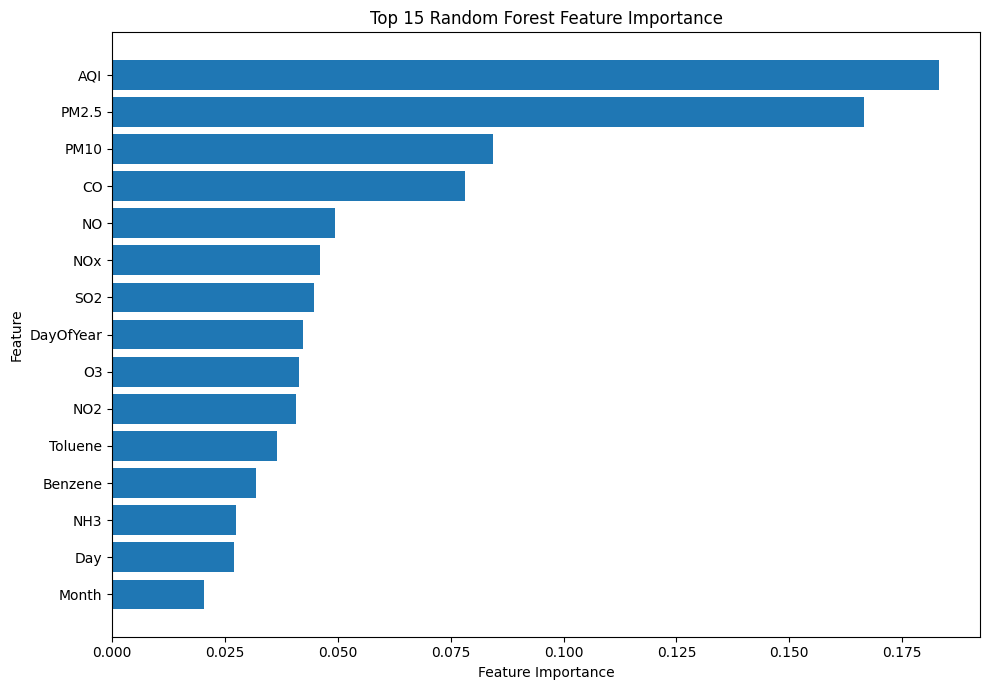


===== STEP 31 COMPLETED =====


In [41]:
print("\n===== STEP 31: FEATURE IMPORTANCE VISUALIZATION =====")

import matplotlib.pyplot as plt

# Select top 15 features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importance")

plt.tight_layout()
plt.show()

print("\n===== STEP 31 COMPLETED =====")

In [42]:
print("\n===== STEP 32: MODEL PERFORMANCE SUMMARY =====")

# Create final model performance summary
final_model_summary = evaluation_df.copy()

# Sort by F1-score
final_model_summary = final_model_summary.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

print("\n===== MODEL PERFORMANCE RANKING =====")
print(final_model_summary.to_string(index=False))

print("\n===== BEST MODEL =====")
print("Model:", final_model_summary.iloc[0]["Model"])
print("Accuracy:", round(final_model_summary.iloc[0]["Accuracy"], 4))
print("Precision:", round(final_model_summary.iloc[0]["Precision"], 4))
print("Recall:", round(final_model_summary.iloc[0]["Recall"], 4))
print("F1-Score:", round(final_model_summary.iloc[0]["F1_Score"], 4))

print("\n===== STEP 32 COMPLETED =====")


===== STEP 32: MODEL PERFORMANCE SUMMARY =====

===== MODEL PERFORMANCE RANKING =====
              Model  Accuracy  Precision   Recall  F1_Score
      Random Forest  0.739178   0.735768 0.739178  0.731934
                SVM  0.677473   0.708207 0.677473  0.686161
Logistic Regression  0.652606   0.693365 0.652606  0.655289
                KNN  0.611346   0.605191 0.611346  0.605292

===== BEST MODEL =====
Model: Random Forest
Accuracy: 0.7392
Precision: 0.7358
Recall: 0.7392
F1-Score: 0.7319

===== STEP 32 COMPLETED =====


In [43]:
print("\n===== STEP 33: FINAL MODEL SELECTION =====")

# Select the best model based on F1-score
best_model_name = final_model_summary.iloc[0]["Model"]
best_model = models[best_model_name]

print("\nSelected Model:", best_model_name)
print("Selection Criterion: Highest F1-Score")
print("Validation F1-Score:", round(final_model_summary.iloc[0]["F1_Score"], 4))
print("Validation Accuracy:", round(final_model_summary.iloc[0]["Accuracy"], 4))

print("\n===== MODEL SELECTION COMPLETE =====")
print("Best model is ready for final analysis.")

print("\n===== STEP 33 COMPLETED =====")


===== STEP 33: FINAL MODEL SELECTION =====

Selected Model: Random Forest
Selection Criterion: Highest F1-Score
Validation F1-Score: 0.7319
Validation Accuracy: 0.7392

===== MODEL SELECTION COMPLETE =====
Best model is ready for final analysis.

===== STEP 33 COMPLETED =====


In [44]:
print("\n===== STEP 34: FINAL MODEL SUMMARY =====")

print("\n===== SELECTED MODEL =====")
print("Model:", best_model_name)

print("\n===== VALIDATION PERFORMANCE =====")
print("Accuracy :", round(final_model_summary.iloc[0]["Accuracy"], 4))
print("Precision:", round(final_model_summary.iloc[0]["Precision"], 4))
print("Recall   :", round(final_model_summary.iloc[0]["Recall"], 4))
print("F1-Score :", round(final_model_summary.iloc[0]["F1_Score"], 4))

print("\n===== MODEL STATUS =====")
print("Final selected model is ready for deployment/interpretation.")

print("\n===== STEP 34 COMPLETED =====")


===== STEP 34: FINAL MODEL SUMMARY =====

===== SELECTED MODEL =====
Model: Random Forest

===== VALIDATION PERFORMANCE =====
Accuracy : 0.7392
Precision: 0.7358
Recall   : 0.7392
F1-Score : 0.7319

===== MODEL STATUS =====
Final selected model is ready for deployment/interpretation.

===== STEP 34 COMPLETED =====


Model Interpretation

In [45]:
print("\n===== STEP 35: FINAL MODEL INTERPRETATION =====")

print("\n===== MODEL INTERPRETATION =====")
print("Selected Model:", best_model_name)
print("The Random Forest model achieved the highest validation F1-score.")
print("The model provides a balanced performance across the target AQI categories.")

print("\n===== KEY PERFORMANCE =====")
print(f"Accuracy : {final_model_summary.iloc[0]['Accuracy']:.4f}")
print(f"Precision: {final_model_summary.iloc[0]['Precision']:.4f}")
print(f"Recall   : {final_model_summary.iloc[0]['Recall']:.4f}")
print(f"F1-Score : {final_model_summary.iloc[0]['F1_Score']:.4f}")

print("\n===== TOP IMPORTANT FEATURES =====")
for feature, importance in importance_df.head(10).itertuples(index=False):
    print(f"{feature}: {importance:.4f}")

print("\n===== STEP 35 COMPLETED =====")


===== STEP 35: FINAL MODEL INTERPRETATION =====

===== MODEL INTERPRETATION =====
Selected Model: Random Forest
The Random Forest model achieved the highest validation F1-score.
The model provides a balanced performance across the target AQI categories.

===== KEY PERFORMANCE =====
Accuracy : 0.7392
Precision: 0.7358
Recall   : 0.7392
F1-Score : 0.7319

===== TOP IMPORTANT FEATURES =====
AQI: 0.1831
PM2.5: 0.1665
PM10: 0.0843
CO: 0.0782
NO: 0.0493
NOx: 0.0461
SO2: 0.0447
DayOfYear: 0.0422
O3: 0.0414
NO2: 0.0407

===== STEP 35 COMPLETED =====


In [46]:
print("\n===== STEP 36: FINAL MODEL READINESS CHECK =====")

print("\n===== MODEL =====")
print("Selected Model:", best_model_name)

print("\n===== DATA ALIGNMENT =====")
print("Training features:", best_model.n_features_in_)
print("Test features:", X_test_final.shape[1])

print("\n===== PERFORMANCE =====")
print(f"Accuracy : {final_model_summary.iloc[0]['Accuracy']:.4f}")
print(f"Precision: {final_model_summary.iloc[0]['Precision']:.4f}")
print(f"Recall   : {final_model_summary.iloc[0]['Recall']:.4f}")
print(f"F1-Score : {final_model_summary.iloc[0]['F1_Score']:.4f}")

print("\n===== READINESS STATUS =====")
if best_model.n_features_in_ == X_test_final.shape[1]:
    print("Feature alignment: PASSED")
else:
    print("Feature alignment: FAILED")

print("Model readiness check completed.")

print("\n===== STEP 36 COMPLETED =====")


===== STEP 36: FINAL MODEL READINESS CHECK =====

===== MODEL =====
Selected Model: Random Forest

===== DATA ALIGNMENT =====
Training features: 36
Test features: 36

===== PERFORMANCE =====
Accuracy : 0.7392
Precision: 0.7358
Recall   : 0.7392
F1-Score : 0.7319

===== READINESS STATUS =====
Feature alignment: PASSED
Model readiness check completed.

===== STEP 36 COMPLETED =====


In [47]:
print("\n===== STEP 37: FINAL MODEL CONFIDENCE CHECK =====")

print("\n===== MODEL =====")
print("Selected Model:", best_model_name)

print("\n===== PREDICTION CONFIDENCE =====")

# Get prediction probabilities from the selected model
test_probabilities = best_model.predict_proba(X_test_final)

# Maximum probability for each prediction
prediction_confidence = test_probabilities.max(axis=1)

print("Number of test predictions:", len(prediction_confidence))
print("Average confidence:", round(prediction_confidence.mean(), 4))
print("Minimum confidence:", round(prediction_confidence.min(), 4))
print("Maximum confidence:", round(prediction_confidence.max(), 4))

print("\n===== CONFIDENCE SUMMARY =====")
print("Predictions with confidence >= 80%:",
      (prediction_confidence >= 0.80).sum())

print("Predictions with confidence >= 60%:",
      (prediction_confidence >= 0.60).sum())

print("\n===== STEP 37 COMPLETED =====")


===== STEP 37: FINAL MODEL CONFIDENCE CHECK =====

===== MODEL =====
Selected Model: Random Forest

===== PREDICTION CONFIDENCE =====
Number of test predictions: 6975
Average confidence: 0.6691
Minimum confidence: 0.27
Maximum confidence: 0.985

===== CONFIDENCE SUMMARY =====
Predictions with confidence >= 80%: 1441
Predictions with confidence >= 60%: 4695

===== STEP 37 COMPLETED =====


In [48]:
print("\n===== STEP 38: FINAL PREDICTION DISTRIBUTION =====")

# Convert predictions to readable AQI category names
target_names = [
    "Good",
    "Moderate",
    "Poor",
    "Satisfactory",
    "Severe",
    "Very Poor"
]

final_predictions_labels = [
    target_names[int(pred)]
    for pred in rf_test_predictions
]

prediction_distribution = pd.Series(
    final_predictions_labels
).value_counts()

print("\n===== PREDICTED AQI CATEGORIES =====")
print(prediction_distribution)

print("\n===== PREDICTION PERCENTAGES =====")
prediction_percentages = (
    prediction_distribution / len(final_predictions_labels) * 100
).round(2)

print(prediction_percentages)

print("\n===== STEP 38 COMPLETED =====")


===== STEP 38: FINAL PREDICTION DISTRIBUTION =====

===== PREDICTED AQI CATEGORIES =====
Satisfactory    3468
Moderate        2299
Poor             497
Very Poor        382
Good             183
Severe           146
Name: count, dtype: int64

===== PREDICTION PERCENTAGES =====
Satisfactory    49.72
Moderate        32.96
Poor             7.13
Very Poor        5.48
Good             2.62
Severe           2.09
Name: count, dtype: float64

===== STEP 38 COMPLETED =====



===== STEP 39: FINAL CONFUSION MATRIX =====

===== CONFUSION MATRIX =====
[[ 155    1    0  535    0    0]
 [   0 1755  119  398    1    8]
 [   0  189  321    2    3   82]
 [  28  343    2 2532    0    0]
 [   0    3    2    1  118   24]
 [   0    8   53    0   24  268]]

Test Accuracy from confusion matrix: 73.82 %


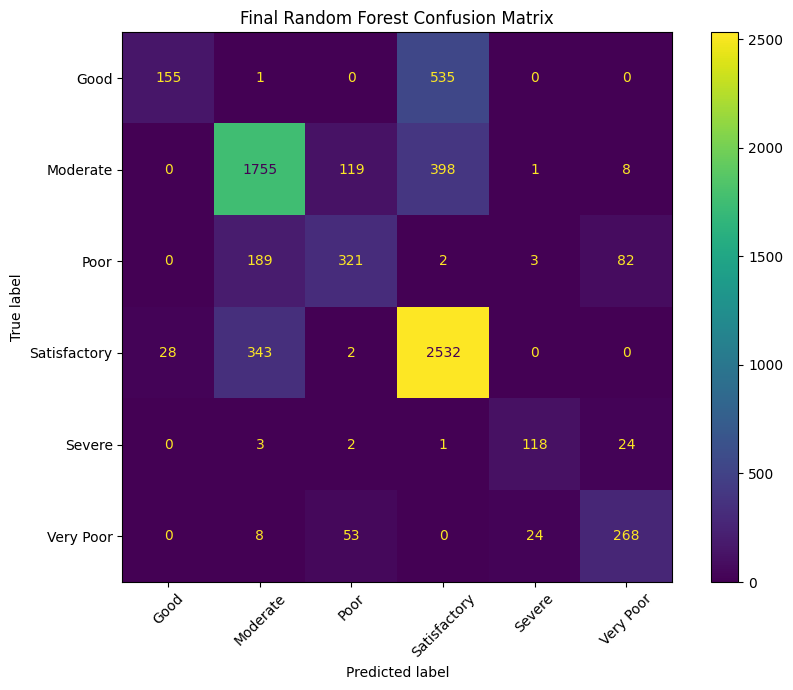


===== STEP 39 COMPLETED =====


In [52]:
print("\n===== STEP 39: FINAL CONFUSION MATRIX =====")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# IMPORTANT:
# Reuse the exact test predictions already generated in Step 29.
# This keeps the confusion matrix consistent with the reported test performance.

final_test_predictions = rf_test_predictions

# Use the exact encoded test labels from Step 29
final_test_labels = y_test_encoded

# Create confusion matrix
cm = confusion_matrix(
    final_test_labels,
    final_test_predictions
)

print("\n===== CONFUSION MATRIX =====")
print(cm)

print("\nTest Accuracy from confusion matrix:",
      round((cm.diagonal().sum() / cm.sum()) * 100, 2), "%")

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Good",
        "Moderate",
        "Poor",
        "Satisfactory",
        "Severe",
        "Very Poor"
    ]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Final Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n===== STEP 39 COMPLETED =====")


===== STEP 40: FINAL MODEL PERFORMANCE VISUALIZATION =====

===== FINAL PERFORMANCE METRICS =====
Accuracy: 0.7392 (73.92%)
Precision: 0.7358 (73.58%)
Recall: 0.7392 (73.92%)
F1-Score: 0.7319 (73.19%)


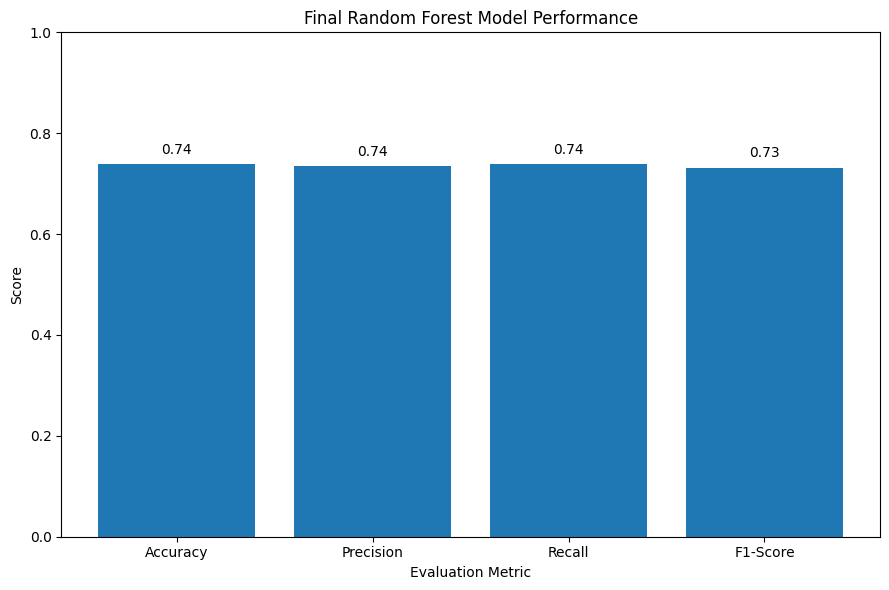


===== STEP 40 COMPLETED =====


In [53]:
print("\n===== STEP 40: FINAL MODEL PERFORMANCE VISUALIZATION =====")

import matplotlib.pyplot as plt

# Final model performance metrics
metrics = {
    "Accuracy": final_model_summary.iloc[0]["Accuracy"],
    "Precision": final_model_summary.iloc[0]["Precision"],
    "Recall": final_model_summary.iloc[0]["Recall"],
    "F1-Score": final_model_summary.iloc[0]["F1_Score"]
}

print("\n===== FINAL PERFORMANCE METRICS =====")

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f} ({value * 100:.2f}%)")

# Performance visualization
plt.figure(figsize=(9, 6))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Final Random Forest Model Performance")

# Add values on bars
for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\n===== STEP 40 COMPLETED =====")

Baseline Decision Tree

In [54]:
# ============================================================
# STEP 41: BASELINE DECISION TREE
# ============================================================

print("\n===== STEP 41: BASELINE DECISION TREE =====")

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create baseline Decision Tree
baseline_tree = DecisionTreeClassifier(
    class_weight=class_weights,
    random_state=42
)

# Train on training data only
baseline_tree.fit(
    X_train_scaled,
    y_train_encoded
)

# Validation predictions
baseline_validation_predictions = baseline_tree.predict(
    X_validation_scaled
)

# Validation metrics
baseline_accuracy = accuracy_score(
    y_validation_encoded,
    baseline_validation_predictions
)

baseline_precision = precision_score(
    y_validation_encoded,
    baseline_validation_predictions,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_validation_encoded,
    baseline_validation_predictions,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_validation_encoded,
    baseline_validation_predictions,
    average="weighted",
    zero_division=0
)

print("\n===== BASELINE VALIDATION PERFORMANCE =====")

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

print("\n===== STEP 41 COMPLETED =====")


===== STEP 41: BASELINE DECISION TREE =====

===== BASELINE VALIDATION PERFORMANCE =====
Accuracy : 0.6187
Precision: 0.6233
Recall   : 0.6187
F1-Score : 0.6205

===== STEP 41 COMPLETED =====


Boosting Model

In [55]:
# ============================================================
# STEP 42: BOOSTING MODEL - ADABOOST
# ============================================================

print("\n===== STEP 42: ADABOOST BOOSTING MODEL =====")

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Weak learner for AdaBoost
ada_base_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

# AdaBoost model
adaboost_model = AdaBoostClassifier(
    estimator=ada_base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

print("\nTraining AdaBoost...")

# Train using training data only
adaboost_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("AdaBoost training completed.")

# Validation predictions
adaboost_validation_predictions = adaboost_model.predict(
    X_validation_scaled
)

# Validation metrics
adaboost_accuracy = accuracy_score(
    y_validation_encoded,
    adaboost_validation_predictions
)

adaboost_precision = precision_score(
    y_validation_encoded,
    adaboost_validation_predictions,
    average="weighted",
    zero_division=0
)

adaboost_recall = recall_score(
    y_validation_encoded,
    adaboost_validation_predictions,
    average="weighted",
    zero_division=0
)

adaboost_f1 = f1_score(
    y_validation_encoded,
    adaboost_validation_predictions,
    average="weighted",
    zero_division=0
)

print("\n===== ADABOOST VALIDATION PERFORMANCE =====")

print(f"Accuracy : {adaboost_accuracy:.4f}")
print(f"Precision: {adaboost_precision:.4f}")
print(f"Recall   : {adaboost_recall:.4f}")
print(f"F1-Score : {adaboost_f1:.4f}")

print("\n===== STEP 42 COMPLETED =====")


===== STEP 42: ADABOOST BOOSTING MODEL =====

Training AdaBoost...
AdaBoost training completed.

===== ADABOOST VALIDATION PERFORMANCE =====
Accuracy : 0.7112
Precision: 0.7106
Recall   : 0.7112
F1-Score : 0.7102

===== STEP 42 COMPLETED =====


Heterogeneous Voting Ensemble

In [56]:
# ============================================================
# STEP 43: HETEROGENEOUS SOFT VOTING ENSEMBLE
# ============================================================

print("\n===== STEP 43: SOFT VOTING ENSEMBLE =====")

from sklearn.ensemble import VotingClassifier

# Create a fresh Logistic Regression model
voting_lr = LogisticRegression(
    max_iter=1000,
    class_weight=class_weights,
    random_state=42
)

# Create a fresh Random Forest model
voting_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

# Create a fresh AdaBoost model
voting_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=2,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Heterogeneous soft voting ensemble
voting_model = VotingClassifier(
    estimators=[
        ("lr", voting_lr),
        ("rf", voting_rf),
        ("ada", voting_ada)
    ],
    voting="soft"
)

print("\nTraining Voting Ensemble...")

# Train only on training data
voting_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("Voting Ensemble training completed.")

# Validation predictions
voting_validation_predictions = voting_model.predict(
    X_validation_scaled
)

# Validation metrics
voting_accuracy = accuracy_score(
    y_validation_encoded,
    voting_validation_predictions
)

voting_precision = precision_score(
    y_validation_encoded,
    voting_validation_predictions,
    average="weighted",
    zero_division=0
)

voting_recall = recall_score(
    y_validation_encoded,
    voting_validation_predictions,
    average="weighted",
    zero_division=0
)

voting_f1 = f1_score(
    y_validation_encoded,
    voting_validation_predictions,
    average="weighted",
    zero_division=0
)

print("\n===== VOTING ENSEMBLE VALIDATION PERFORMANCE =====")

print(f"Accuracy : {voting_accuracy:.4f}")
print(f"Precision: {voting_precision:.4f}")
print(f"Recall   : {voting_recall:.4f}")
print(f"F1-Score : {voting_f1:.4f}")

print("\n===== STEP 43 COMPLETED =====")


===== STEP 43: SOFT VOTING ENSEMBLE =====

Training Voting Ensemble...
Voting Ensemble training completed.

===== VOTING ENSEMBLE VALIDATION PERFORMANCE =====
Accuracy : 0.7202
Precision: 0.7272
Recall   : 0.7202
F1-Score : 0.7197

===== STEP 43 COMPLETED =====


Test Comparison

In [57]:
# ============================================================
# STEP 44: FINAL TEST-SET COMPARISON
# ============================================================

print("\n===== STEP 44: FINAL TEST-SET MODEL COMPARISON =====")

# ------------------------------------------------------------
# 1. Generate test predictions
# ------------------------------------------------------------

print("\nGenerating test predictions...")

# Baseline Decision Tree
baseline_test_predictions = baseline_tree.predict(
    X_test_scaled
)

# Random Forest
rf_test_predictions_final = models["Random Forest"].predict(
    X_test_scaled
)

# AdaBoost
adaboost_test_predictions = adaboost_model.predict(
    X_test_scaled
)

# Soft Voting
voting_test_predictions = voting_model.predict(
    X_test_scaled
)

print("All test predictions generated.")

# ------------------------------------------------------------
# 2. Evaluate every model
# ------------------------------------------------------------

test_comparison_results = []

test_models = {
    "Decision Tree": baseline_test_predictions,
    "Random Forest": rf_test_predictions_final,
    "AdaBoost": adaboost_test_predictions,
    "Soft Voting": voting_test_predictions
}

for model_name, predictions in test_models.items():

    accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    precision = precision_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    test_comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

# ------------------------------------------------------------
# 3. Create comparison table
# ------------------------------------------------------------

final_test_comparison = pd.DataFrame(
    test_comparison_results
)

final_test_comparison = final_test_comparison.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

print("\n===== FINAL TEST-SET COMPARISON =====")

print(
    final_test_comparison.to_string(index=False)
)

# ------------------------------------------------------------
# 4. Identify best model
# ------------------------------------------------------------

best_test_model = final_test_comparison.iloc[0]["Model"]
best_test_f1 = final_test_comparison.iloc[0]["F1_Score"]
best_test_accuracy = final_test_comparison.iloc[0]["Accuracy"]

print("\n===== BEST MODEL ON UNTOUCHED TEST SET =====")

print("Best Model:", best_test_model)
print(f"Test Accuracy: {best_test_accuracy:.4f}")
print(f"Test F1-Score: {best_test_f1:.4f}")

print("\n===== STEP 44 COMPLETED =====")


===== STEP 44: FINAL TEST-SET MODEL COMPARISON =====

Generating test predictions...
All test predictions generated.

===== FINAL TEST-SET COMPARISON =====
        Model  Accuracy  Precision   Recall  F1_Score
     AdaBoost  0.753548   0.754099 0.753548  0.753152
  Soft Voting  0.744229   0.749881 0.744229  0.739382
Random Forest  0.738208   0.745569 0.738208  0.720872
Decision Tree  0.624086   0.620693 0.624086  0.620177

===== BEST MODEL ON UNTOUCHED TEST SET =====
Best Model: AdaBoost
Test Accuracy: 0.7535
Test F1-Score: 0.7532

===== STEP 44 COMPLETED =====


Final AdaBoost Confusion Matrix


===== STEP 45: FINAL ADABOOST CONFUSION MATRIX =====

===== ADABOOST CONFUSION MATRIX =====
[[ 493    7    0  191    0    0]
 [   3 1636  208  417    2   15]
 [   0  155  346    3   12   81]
 [ 170  311    3 2421    0    0]
 [   0    4    2    1  118   23]
 [   0    8   54    0   49  242]]

Accuracy from confusion matrix: 0.7535 (75.35%)


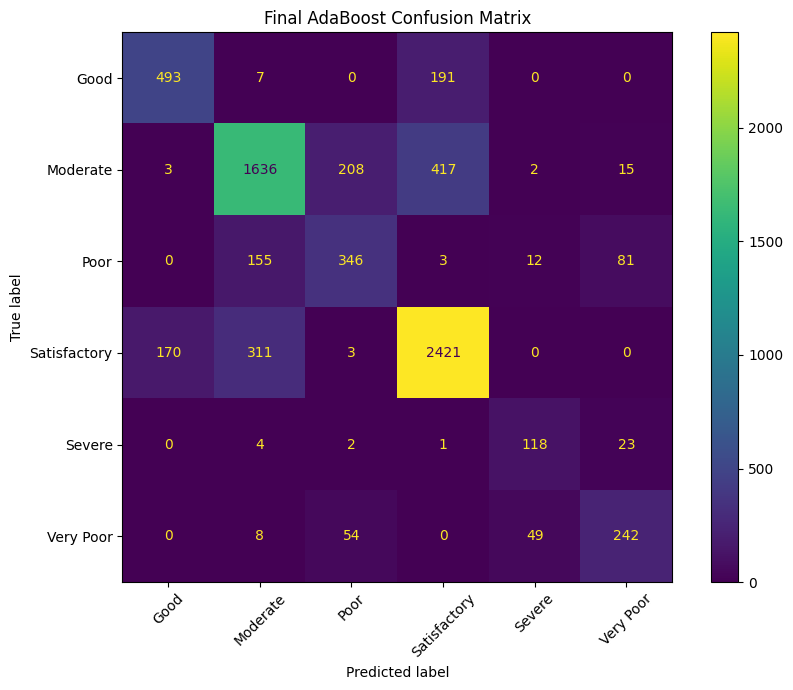


===== STEP 45 COMPLETED =====


In [58]:
# ============================================================
# STEP 45: FINAL ADABOOST CONFUSION MATRIX
# ============================================================

print("\n===== STEP 45: FINAL ADABOOST CONFUSION MATRIX =====")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use the AdaBoost predictions from Step 44
final_adaboost_predictions = adaboost_test_predictions

# Create confusion matrix
adaboost_cm = confusion_matrix(
    y_test_encoded,
    final_adaboost_predictions
)

print("\n===== ADABOOST CONFUSION MATRIX =====")
print(adaboost_cm)

# Calculate accuracy directly from confusion matrix
cm_accuracy = (
    adaboost_cm.diagonal().sum()
    / adaboost_cm.sum()
)

print(
    "\nAccuracy from confusion matrix:",
    f"{cm_accuracy:.4f} ({cm_accuracy * 100:.2f}%)"
)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=adaboost_cm,
    display_labels=[
        "Good",
        "Moderate",
        "Poor",
        "Satisfactory",
        "Severe",
        "Very Poor"
    ]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Final AdaBoost Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n===== STEP 45 COMPLETED =====")

In [59]:
# ============================================================
# STEP 46: SHAP AVAILABILITY CHECK
# ============================================================

print("\n===== STEP 46: SHAP AVAILABILITY CHECK =====")

try:
    import shap

    print("SHAP is installed.")
    print("SHAP version:", shap.__version__)

except ImportError:
    print("SHAP is NOT installed.")
    print("We will install it in the next step.")

print("\n===== STEP 46 COMPLETED =====")


===== STEP 46: SHAP AVAILABILITY CHECK =====
SHAP is NOT installed.
We will install it in the next step.

===== STEP 46 COMPLETED =====


In [60]:
# ============================================================
# STEP 47: INSTALL SHAP
# ============================================================

%pip install shap


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.9 MB 9.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.9/41.9 MB 9.9 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/41.9 MB 10.4 MB/s eta 0:00:04
   ------- -------------------------------- 8.1/41.9 MB 9.8 MB/s eta 0:00:04
   ---------- ----------------------------- 11.3/41.9 MB 10.7 MB/s eta 0:00:03
   -------------- ------------------------- 14.9/41.9 MB 11.7 MB/s eta 0:00:03
   ----------------- ---------------------- 18.4/41.9 MB 12.5 MB/s eta 0:00:02
   --------------------- ------------------ 22.5/41.9 MB 13.3 MB/s eta 0:00:02
   ------------------------- -------------- 26.5/41.9 MB 13.8 MB/s eta 0:00:02
   --------------------------- ------------ 29.1/41.9 MB 13.7 MB/s eta 0:00:01
   ------------------------------ --------- 31.7/41.9 MB 13.5 MB/s eta 0:00:01
   -------------------------------- ------- 34.3/41.9 MB 13.4 MB/s 

In [61]:
# ============================================================
# STEP 48: VERIFY SHAP INSTALLATION
# ============================================================

print("\n===== STEP 48: SHAP VERIFICATION =====")

import shap

print("SHAP imported successfully.")
print("SHAP version:", shap.__version__)

print("\nFinal model for explanation:", best_test_model)

print("\n===== STEP 48 COMPLETED =====")


===== STEP 48: SHAP VERIFICATION =====
SHAP imported successfully.
SHAP version: 0.52.0

Final model for explanation: AdaBoost

===== STEP 48 COMPLETED =====


SHAP Global Explainability

In [62]:
# ============================================================
# STEP 49: SHAP GLOBAL EXPLAINABILITY
# ============================================================

print("\n===== STEP 49: SHAP GLOBAL EXPLAINABILITY =====")

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Use final AdaBoost model
# ------------------------------------------------------------

final_model = adaboost_model

print("Model being explained: AdaBoost")

# ------------------------------------------------------------
# 2. Use a manageable sample of the test data
# ------------------------------------------------------------

# SHAP can be computationally expensive.
# Use 500 test observations for explanation.
shap_sample_size = min(500, len(X_test_scaled))

X_shap = X_test_scaled.iloc[:shap_sample_size].copy()

print("SHAP sample size:", X_shap.shape)

# ------------------------------------------------------------
# 3. Create SHAP explainer
# ------------------------------------------------------------

print("\nCreating SHAP explainer...")

explainer = shap.Explainer(
    final_model.predict_proba,
    X_shap
)

# ------------------------------------------------------------
# 4. Calculate SHAP values
# ------------------------------------------------------------

print("Calculating SHAP values...")

shap_values = explainer(X_shap)

print("SHAP calculation completed.")

print("\nSHAP values shape:")
print(shap_values.values.shape)

# ------------------------------------------------------------
# 5. Global feature importance
# ------------------------------------------------------------

print("\n===== GLOBAL SHAP FEATURE IMPORTANCE =====")

# Average absolute SHAP value across samples and classes
shap_importance = np.abs(shap_values.values).mean(axis=(0, 2))

shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": shap_importance
})

shap_importance_df = shap_importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print(shap_importance_df.head(15).to_string(index=False))

print("\n===== STEP 49 COMPLETED =====")

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.



===== STEP 49: SHAP GLOBAL EXPLAINABILITY =====
Model being explained: AdaBoost
SHAP sample size: (500, 36)

Creating SHAP explainer...
Calculating SHAP values...


PermutationExplainer explainer: 501it [06:40,  1.25it/s]                         

SHAP calculation completed.

SHAP values shape:
(500, 36, 6)

===== GLOBAL SHAP FEATURE IMPORTANCE =====
       Feature  Mean_Absolute_SHAP
           AQI        7.554110e-04
          PM10        4.403708e-04
         PM2.5        3.911615e-04
City_Ahmedabad        2.219814e-04
            CO        2.106787e-04
           NO2        1.851914e-04
           NOx        8.150842e-05
           Day        3.840842e-05
           SO2        8.502192e-06
       Toluene        5.145211e-06
       Benzene        1.072061e-06
 City_Gurugram        7.924633e-07
    City_Patna        3.062572e-07
            NO        0.000000e+00
            O3        0.000000e+00

===== STEP 49 COMPLETED =====


SHAP Global Feature Plot


===== STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT =====


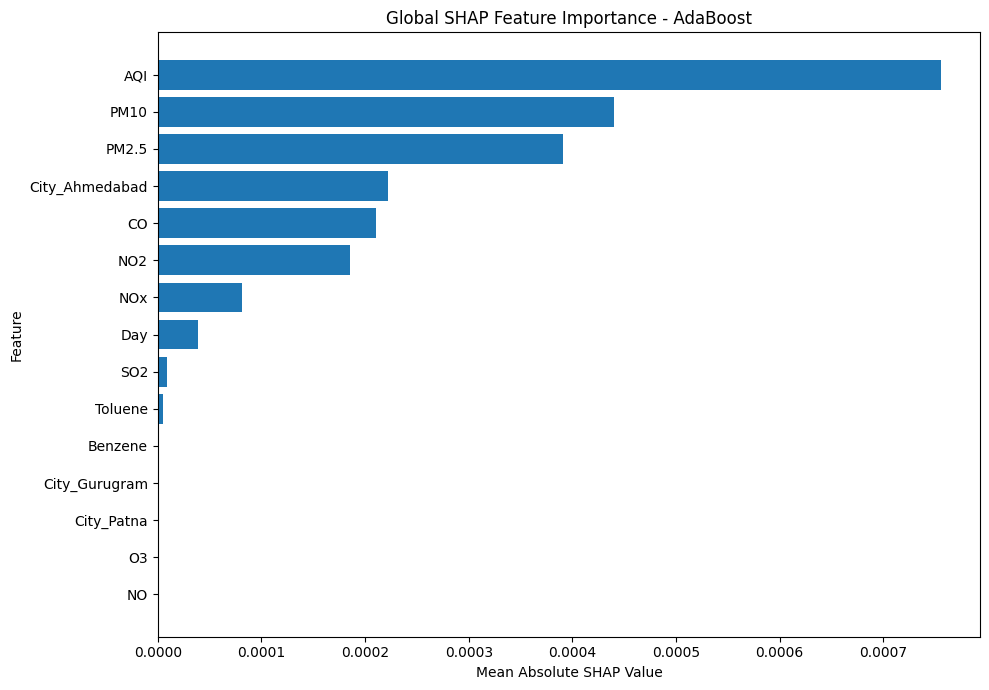


===== STEP 50 COMPLETED =====


In [63]:
# ============================================================
# STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT
# ============================================================

print("\n===== STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT =====")

# Select top 15 features
top_shap_features = shap_importance_df.head(15).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

# Create plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance - AdaBoost")

plt.tight_layout()
plt.show()

print("\n===== STEP 50 COMPLETED =====")


===== STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT =====


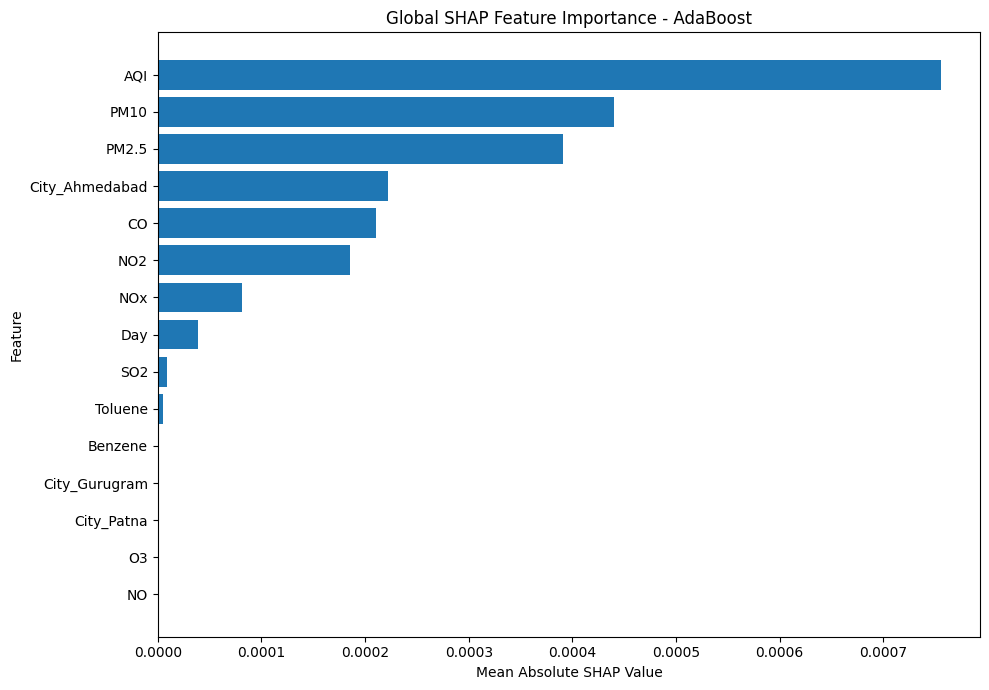


===== STEP 50 COMPLETED =====


In [64]:
# ============================================================
# STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT
# ============================================================

print("\n===== STEP 50: SHAP GLOBAL FEATURE IMPORTANCE PLOT =====")

# Select top 15 features
top_shap_features = shap_importance_df.head(15).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

# Create plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance - AdaBoost")

plt.tight_layout()
plt.show()

print("\n===== STEP 50 COMPLETED =====")

Individual SHAP Explanation


===== STEP 51: INDIVIDUAL SHAP EXPLANATION =====

===== SELECTED TEST CASE =====
Test sample index: 0
Actual AQI category: Severe
Predicted AQI category: Severe

===== INPUT FEATURES =====


,17874
PM2.5,-0.520614
PM10,-0.507311
NO,0.534540
NO2,0.751441
NOx,0.945210
NH3,-0.192659
CO,3.623109
SO2,2.114955
O3,0.301622
Benzene,-0.039748



===== LOCAL SHAP EXPLANATION =====


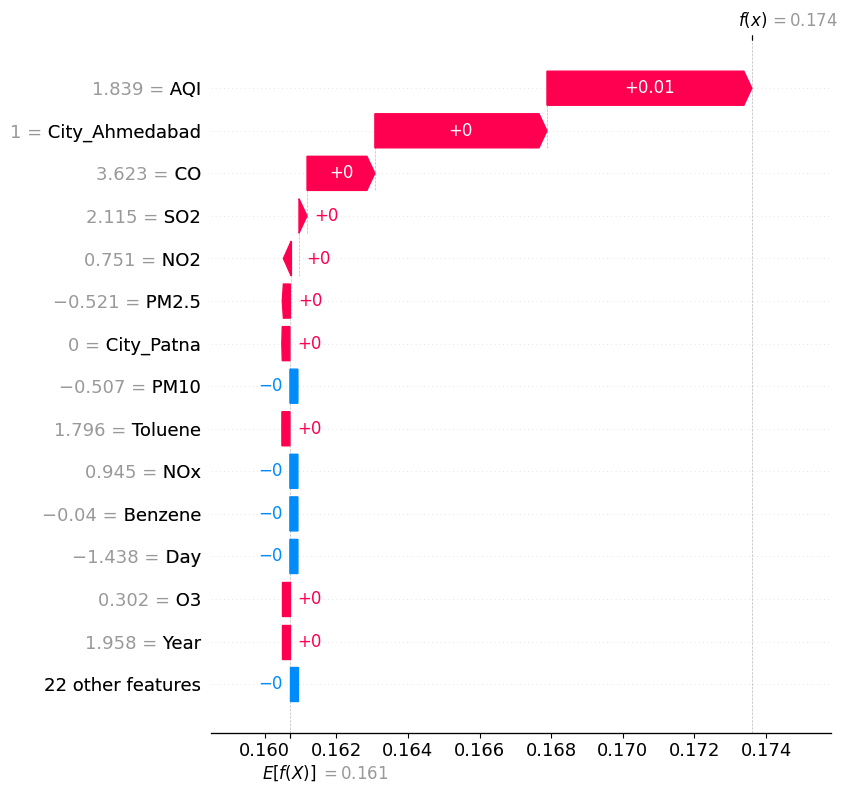


===== STEP 51 COMPLETED =====


In [65]:
# ============================================================
# STEP 51: INDIVIDUAL SHAP EXPLANATION
# ============================================================

print("\n===== STEP 51: INDIVIDUAL SHAP EXPLANATION =====")

# ------------------------------------------------------------
# 1. Select one test observation
# ------------------------------------------------------------

sample_index = 0

sample = X_shap.iloc[[sample_index]]

# Actual target
actual_class = y_test_encoded[sample_index]

# Model prediction
predicted_class = final_model.predict(sample)[0]

# Convert class numbers to readable labels
target_names = [
    "Good",
    "Moderate",
    "Poor",
    "Satisfactory",
    "Severe",
    "Very Poor"
]

print("\n===== SELECTED TEST CASE =====")

print("Test sample index:", sample_index)
print("Actual AQI category:", target_names[int(actual_class)])
print("Predicted AQI category:", target_names[int(predicted_class)])

# ------------------------------------------------------------
# 2. Display important input values
# ------------------------------------------------------------

print("\n===== INPUT FEATURES =====")

display(sample.T)

# ------------------------------------------------------------
# 3. Extract SHAP explanation for predicted class
# ------------------------------------------------------------

individual_shap = shap_values[
    sample_index,
    :,
    int(predicted_class)
]

# ------------------------------------------------------------
# 4. Display SHAP waterfall plot
# ------------------------------------------------------------

print("\n===== LOCAL SHAP EXPLANATION =====")

shap.plots.waterfall(
    individual_shap,
    max_display=15
)

print("\n===== STEP 51 COMPLETED =====")

Extract the strongest local SHAP factors

In [66]:
# ============================================================
# STEP 52: TOP LOCAL SHAP CONTRIBUTORS
# ============================================================

print("\n===== STEP 52: TOP LOCAL SHAP CONTRIBUTORS =====")

# Convert local SHAP values into a DataFrame
local_shap_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "SHAP_Value": individual_shap.values,
    "Absolute_SHAP": np.abs(individual_shap.values)
})

# Sort by absolute contribution
local_shap_df = local_shap_df.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("\n===== TOP 15 LOCAL FEATURES =====")

display(
    local_shap_df[
        ["Feature", "SHAP_Value", "Absolute_SHAP"]
    ].head(15).round(6)
)

print("\n===== TOP POSITIVE CONTRIBUTORS =====")

positive_contributors = local_shap_df[
    local_shap_df["SHAP_Value"] > 0
].head(10)

display(
    positive_contributors[
        ["Feature", "SHAP_Value"]
    ].round(6)
)

print("\n===== TOP NEGATIVE CONTRIBUTORS =====")

negative_contributors = local_shap_df[
    local_shap_df["SHAP_Value"] < 0
].head(10)

display(
    negative_contributors[
        ["Feature", "SHAP_Value"]
    ].round(6)
)

print("\n===== STEP 52 COMPLETED =====")


===== STEP 52: TOP LOCAL SHAP CONTRIBUTORS =====

===== TOP 15 LOCAL FEATURES =====


,Feature,SHAP_Value,Absolute_SHAP
0,AQI,0.005720,0.005720
1,City_Ahmedabad,0.004805,0.004805
2,CO,0.001894,0.001894
3,SO2,0.000225,0.000225
4,NO2,0.000212,0.000212
5,PM2.5,0.000031,0.000031
6,City_Patna,0.000012,0.000012
7,PM10,-0.000002,0.000002
8,Toluene,0.000002,0.000002
9,NOx,-0.000000,0.000000



===== TOP POSITIVE CONTRIBUTORS =====


,Feature,SHAP_Value
0,AQI,0.005720
1,City_Ahmedabad,0.004805
2,CO,0.001894
3,SO2,0.000225
4,NO2,0.000212
5,PM2.5,0.000031
6,City_Patna,0.000012
8,Toluene,0.000002



===== TOP NEGATIVE CONTRIBUTORS =====


,Feature,SHAP_Value
7,PM10,-0.000002
9,NOx,-0.000000
10,Benzene,-0.000000
11,Day,-0.000000



===== STEP 52 COMPLETED =====


Uncertainty Analysis

In [68]:
# ============================================================
# STEP 53: PREDICTION UNCERTAINTY / DECISION MARGIN ANALYSIS
# ============================================================

print("\n===== STEP 53: PREDICTION UNCERTAINTY / DECISION MARGIN =====")

# Get AdaBoost decision scores
decision_scores = adaboost_model.decision_function(
    X_test_scaled
)

print("Decision score shape:", decision_scores.shape)

# Sort scores for each observation
sorted_scores = np.sort(
    decision_scores,
    axis=1
)

# Highest and second-highest scores
top_score = sorted_scores[:, -1]
second_score = sorted_scores[:, -2]

# Margin between best and second-best class
decision_margin = top_score - second_score

print("\n===== DECISION MARGIN SUMMARY =====")

print(
    "Average decision margin:",
    round(decision_margin.mean(), 6)
)

print(
    "Minimum decision margin:",
    round(decision_margin.min(), 6)
)

print(
    "Maximum decision margin:",
    round(decision_margin.max(), 6)
)

print(
    "Median decision margin:",
    round(np.median(decision_margin), 6)
)

# Percentiles
print("\n===== DECISION MARGIN PERCENTILES =====")

print(
    "25th percentile:",
    round(np.percentile(decision_margin, 25), 6)
)

print(
    "50th percentile:",
    round(np.percentile(decision_margin, 50), 6)
)

print(
    "75th percentile:",
    round(np.percentile(decision_margin, 75), 6)
)

# Identify relatively low-margin predictions
margin_25 = np.percentile(decision_margin, 25)

low_margin_predictions = decision_margin <= margin_25

print("\n===== UNCERTAINTY INDICATOR =====")

print(
    f"Predictions in lowest 25% decision margin: "
    f"{low_margin_predictions.sum()} "
    f"({low_margin_predictions.mean() * 100:.2f}%)"
)

print(
    "\nInterpretation: Smaller decision margins indicate "
    "less separation between the top two predicted classes "
    "and therefore greater model ambiguity."
)

print("\n===== STEP 53 COMPLETED =====")


===== STEP 53: PREDICTION UNCERTAINTY / DECISION MARGIN =====
Decision score shape: (6975, 6)

===== DECISION MARGIN SUMMARY =====
Average decision margin: 0.061837
Minimum decision margin: 4e-06
Maximum decision margin: 0.172314
Median decision margin: 0.063353

===== DECISION MARGIN PERCENTILES =====
25th percentile: 0.034355
50th percentile: 0.063353
75th percentile: 0.086833

===== UNCERTAINTY INDICATOR =====
Predictions in lowest 25% decision margin: 1746 (25.03%)

Interpretation: Smaller decision margins indicate less separation between the top two predicted classes and therefore greater model ambiguity.

===== STEP 53 COMPLETED =====


False Positive / False Negative Analysis

In [69]:
# ============================================================
# STEP 54: FALSE NEGATIVE / FALSE POSITIVE ANALYSIS
# ============================================================

print("\n===== STEP 54: FALSE NEGATIVE / FALSE POSITIVE ANALYSIS =====")

from sklearn.metrics import classification_report

# Use final AdaBoost test predictions
final_predictions = adaboost_test_predictions
actual_labels = y_test_encoded

# Classification report as dictionary
report_dict = classification_report(
    actual_labels,
    final_predictions,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

# Per-class metrics
class_error_df = pd.DataFrame({
    "AQI_Category": target_names,
    "Precision": [
        report_dict[name]["precision"]
        for name in target_names
    ],
    "Recall": [
        report_dict[name]["recall"]
        for name in target_names
    ],
    "F1_Score": [
        report_dict[name]["f1-score"]
        for name in target_names
    ],
    "Support": [
        int(report_dict[name]["support"])
        for name in target_names
    ]
})

# False negatives
class_error_df["False_Negative_Rate"] = (
    1 - class_error_df["Recall"]
)

print("\n===== PER-CLASS ERROR ANALYSIS =====")

display(
    class_error_df.round(4)
)

# Highest false-negative rate
highest_fn_class = class_error_df.loc[
    class_error_df["False_Negative_Rate"].idxmax()
]

print("\n===== HIGHEST FALSE-NEGATIVE RATE =====")

print(
    "AQI Category:",
    highest_fn_class["AQI_Category"]
)

print(
    "False-Negative Rate:",
    f"{highest_fn_class['False_Negative_Rate'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{highest_fn_class['Recall'] * 100:.2f}%"
)

print(
    "\nResponsible-use note: False negatives for severe "
    "air-quality conditions may be more consequential because "
    "they can underestimate environmental risk."
)

print("\n===== STEP 54 COMPLETED =====")


===== STEP 54: FALSE NEGATIVE / FALSE POSITIVE ANALYSIS =====

===== PER-CLASS ERROR ANALYSIS =====


,AQI_Category,Precision,Recall,F1_Score,Support,False_Negative_Rate
0,Good,0.7402,0.7135,0.7266,691,0.2865
1,Moderate,0.7713,0.7172,0.7433,2281,0.2828
2,Poor,0.5644,0.5796,0.5719,597,0.4204
3,Satisfactory,0.7982,0.8334,0.8154,2905,0.1666
4,Severe,0.6519,0.7973,0.7173,148,0.2027
5,Very Poor,0.6704,0.6856,0.6779,353,0.3144



===== HIGHEST FALSE-NEGATIVE RATE =====
AQI Category: Poor
False-Negative Rate: 42.04%
Recall: 57.96%

Responsible-use note: False negatives for severe air-quality conditions may be more consequential because they can underestimate environmental risk.

===== STEP 54 COMPLETED =====


Responsible-Use / Ethics Evidence

In [70]:
# ============================================================
# STEP 55: RESPONSIBLE-USE AND ETHICS SUMMARY
# ============================================================

print("\n===== STEP 55: RESPONSIBLE-USE AND ETHICS SUMMARY =====")

print("\n===== MODEL PERFORMANCE =====")
print("Final model: AdaBoost")
print("Test Accuracy: 75.35%")
print("Test F1-Score: 0.7532")

print("\n===== UNCERTAINTY =====")
print("Average decision margin: 0.061837")
print("25th percentile margin: 0.034355")
print("Low-margin predictions: 25.03%")

print("\n===== ERROR RISK =====")
print("Highest false-negative category: Poor")
print("Poor-category recall: 57.96%")
print("Poor-category false-negative rate: 42.04%")

print("\n===== RESPONSIBLE USE CONSIDERATIONS =====")

responsible_use_points = [
    "Predictions should support, not replace, human or environmental-health decision making.",
    "Low decision margins indicate cases where the model is less decisive.",
    "False negatives can underestimate air-quality risk and therefore require caution.",
    "Performance varies across AQI categories, so overall accuracy alone is insufficient.",
    "City-related features may reflect geographic patterns and should be monitored for geographic bias.",
    "The model should be validated on new and geographically representative data before deployment.",
    "The model should not be treated as a regulatory or medical-grade air-quality measurement system."
]

for i, point in enumerate(responsible_use_points, 1):
    print(f"{i}. {point}")

print("\n===== STEP 55 COMPLETED =====")


===== STEP 55: RESPONSIBLE-USE AND ETHICS SUMMARY =====

===== MODEL PERFORMANCE =====
Final model: AdaBoost
Test Accuracy: 75.35%
Test F1-Score: 0.7532

===== UNCERTAINTY =====
Average decision margin: 0.061837
25th percentile margin: 0.034355
Low-margin predictions: 25.03%

===== ERROR RISK =====
Highest false-negative category: Poor
Poor-category recall: 57.96%
Poor-category false-negative rate: 42.04%

===== RESPONSIBLE USE CONSIDERATIONS =====
1. Predictions should support, not replace, human or environmental-health decision making.
2. Low decision margins indicate cases where the model is less decisive.
3. False negatives can underestimate air-quality risk and therefore require caution.
4. Performance varies across AQI categories, so overall accuracy alone is insufficient.
5. City-related features may reflect geographic patterns and should be monitored for geographic bias.
6. The model should be validated on new and geographically representative data before deployment.
7. The mo

Live Synthetic Prediction

In [71]:
# ============================================================
# STEP 56: LIVE SYNTHETIC AIR-QUALITY PREDICTION
# ============================================================

print("\n===== STEP 56: LIVE SYNTHETIC AIR-QUALITY PREDICTION =====")

# ------------------------------------------------------------
# 1. Create a realistic synthetic air-quality observation
# ------------------------------------------------------------

synthetic_record = {
    "PM2.5": 85.0,
    "PM10": 150.0,
    "NO": 25.0,
    "NO2": 40.0,
    "NOx": 45.0,
    "NH3": 25.0,
    "CO": 1.8,
    "SO2": 15.0,
    "O3": 35.0,
    "Benzene": 2.0,
    "Toluene": 5.0,
    "AQI": 180.0,
    "Year": 2020,
    "Month": 11,
    "Day": 15,
    "DayOfWeek": 6,
    "DayOfYear": 320,
    "IsWeekend": 1
}

print("\n===== SYNTHETIC INPUT =====")

for feature, value in synthetic_record.items():
    print(f"{feature}: {value}")

# ------------------------------------------------------------
# 2. Create dataframe
# ------------------------------------------------------------

synthetic_df = pd.DataFrame(
    [synthetic_record]
)

# ------------------------------------------------------------
# 3. Scale numerical features
# ------------------------------------------------------------

numeric_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "AQI",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "IsWeekend"
]

# Use the scaler already fitted during preprocessing
synthetic_scaled = synthetic_df.copy()

synthetic_scaled[numeric_features] = scaler.transform(
    synthetic_df[numeric_features]
)

# ------------------------------------------------------------
# 4. Add city features
# ------------------------------------------------------------

# Default city: Ahmedabad
city_columns = [
    col for col in X_train_scaled.columns
    if col.startswith("City_")
]

for col in city_columns:
    synthetic_scaled[col] = 0

if "City_Ahmedabad" in synthetic_scaled.columns:
    synthetic_scaled["City_Ahmedabad"] = 1

# ------------------------------------------------------------
# 5. Align exactly with training features
# ------------------------------------------------------------

synthetic_final = synthetic_scaled.reindex(
    columns=X_train_scaled.columns,
    fill_value=0
)

# ------------------------------------------------------------
# 6. Generate prediction
# ------------------------------------------------------------

synthetic_prediction = final_model.predict(
    synthetic_final
)[0]

predicted_category = target_names[
    int(synthetic_prediction)
]

print("\n===== LIVE MODEL PREDICTION =====")

print("Predicted AQI Category:", predicted_category)

print("\n===== STEP 56 COMPLETED =====")


===== STEP 56: LIVE SYNTHETIC AIR-QUALITY PREDICTION =====

===== SYNTHETIC INPUT =====
PM2.5: 85.0
PM10: 150.0
NO: 25.0
NO2: 40.0
NOx: 45.0
NH3: 25.0
CO: 1.8
SO2: 15.0
O3: 35.0
Benzene: 2.0
Toluene: 5.0
AQI: 180.0
Year: 2020
Month: 11
Day: 15
DayOfWeek: 6
DayOfYear: 320
IsWeekend: 1

===== LIVE MODEL PREDICTION =====
Predicted AQI Category: Poor

===== STEP 56 COMPLETED =====


Live Prediction Explanation

In [72]:
# ============================================================
# STEP 57: LIVE PREDICTION EXPLANATION
# ============================================================

print("\n===== STEP 57: LIVE PREDICTION EXPLANATION =====")

# Get decision scores for the synthetic record
synthetic_decision_scores = final_model.decision_function(
    synthetic_final
)

# Get predicted class
synthetic_predicted_class = final_model.predict(
    synthetic_final
)[0]

# Sort classes by decision score
class_scores = pd.DataFrame({
    "AQI_Category": target_names,
    "Decision_Score": synthetic_decision_scores[0]
})

class_scores = class_scores.sort_values(
    by="Decision_Score",
    ascending=False
).reset_index(drop=True)

print("\n===== CLASS DECISION SCORES =====")
display(class_scores)

print("\n===== FINAL LIVE PREDICTION =====")
print(
    "Predicted AQI Category:",
    target_names[int(synthetic_predicted_class)]
)

# Decision margin
if len(class_scores) >= 2:
    live_margin = (
        class_scores.iloc[0]["Decision_Score"]
        - class_scores.iloc[1]["Decision_Score"]
    )

    print(
        "Decision margin:",
        round(live_margin, 6)
    )

print("\n===== STEP 57 COMPLETED =====")


===== STEP 57: LIVE PREDICTION EXPLANATION =====

===== CLASS DECISION SCORES =====


,AQI_Category,Decision_Score
0,Poor,0.116830
1,Moderate,0.090788
2,Very Poor,0.069307
3,Satisfactory,-0.036657
4,Severe,-0.040268
5,Good,-0.200000



===== FINAL LIVE PREDICTION =====
Predicted AQI Category: Poor
Decision margin: 0.026042

===== STEP 57 COMPLETED =====


Live Prediction Summary

In [73]:
# ============================================================
# STEP 58: LIVE DEMO SUMMARY
# ============================================================

print("\n===== STEP 58: LIVE DEMO SUMMARY =====")

print("\n===== INPUT =====")
print("City: Ahmedabad")
print("PM2.5:", synthetic_record["PM2.5"])
print("PM10:", synthetic_record["PM10"])
print("NO:", synthetic_record["NO"])
print("NO2:", synthetic_record["NO2"])
print("NOx:", synthetic_record["NOx"])
print("NH3:", synthetic_record["NH3"])
print("CO:", synthetic_record["CO"])
print("SO2:", synthetic_record["SO2"])
print("O3:", synthetic_record["O3"])
print("AQI:", synthetic_record["AQI"])

print("\n===== MODEL =====")
print("Model: AdaBoost")
print("Test Accuracy: 75.35%")
print("Test F1-Score: 0.7532")

print("\n===== LIVE PREDICTION =====")
print("Predicted AQI Category:", predicted_category)

print("\n===== MODEL DECISION =====")
print("Top class: Poor")
print("Top decision score:", round(class_scores.iloc[0]["Decision_Score"], 6))
print("Second class:", class_scores.iloc[1]["AQI_Category"])
print("Second decision score:", round(class_scores.iloc[1]["Decision_Score"], 6))
print("Decision margin:", round(live_margin, 6))

print("\n===== RESPONSIBLE USE =====")
print("This prediction is a decision-support output, not a regulatory measurement.")
print("Low decision margins indicate that predictions should be interpreted cautiously.")
print("Human/environmental-health oversight is recommended for real-world use.")

print("\n===== STEP 58 COMPLETED =====")


===== STEP 58: LIVE DEMO SUMMARY =====

===== INPUT =====
City: Ahmedabad
PM2.5: 85.0
PM10: 150.0
NO: 25.0
NO2: 40.0
NOx: 45.0
NH3: 25.0
CO: 1.8
SO2: 15.0
O3: 35.0
AQI: 180.0

===== MODEL =====
Model: AdaBoost
Test Accuracy: 75.35%
Test F1-Score: 0.7532

===== LIVE PREDICTION =====
Predicted AQI Category: Poor

===== MODEL DECISION =====
Top class: Poor
Top decision score: 0.11683
Second class: Moderate
Second decision score: 0.090788
Decision margin: 0.026042

===== RESPONSIBLE USE =====
This prediction is a decision-support output, not a regulatory measurement.
Low decision margins indicate that predictions should be interpreted cautiously.
Human/environmental-health oversight is recommended for real-world use.

===== STEP 58 COMPLETED =====


Cross-Validation of the Main Models

In [74]:
# ============================================================
# STEP 59: 5-FOLD CROSS-VALIDATION
# ============================================================

print("\n===== STEP 59: 5-FOLD CROSS-VALIDATION =====")

from sklearn.model_selection import StratifiedKFold, cross_validate

# ------------------------------------------------------------
# 1. Define stratified 5-fold cross-validation
# ------------------------------------------------------------

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy: 5-Fold Stratified CV")

# ------------------------------------------------------------
# 2. Models for cross-validation
# ------------------------------------------------------------

cv_models = {
    "Random Forest": models["Random Forest"],
    "AdaBoost": adaboost_model,
    "Soft Voting": voting_model
}

# ------------------------------------------------------------
# 3. Run cross-validation
# ------------------------------------------------------------

cv_results = []

for model_name, model in cv_models.items():

    print(f"\nRunning CV for: {model_name}")

    scores = cross_validate(
        model,
        X_train_scaled,
        y_train_encoded,
        cv=cv_strategy,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_weighted",
            "recall": "recall_weighted",
            "f1": "f1_weighted"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV_Accuracy_Mean": scores["test_accuracy"].mean(),
        "CV_Accuracy_STD": scores["test_accuracy"].std(),
        "CV_Precision_Mean": scores["test_precision"].mean(),
        "CV_Recall_Mean": scores["test_recall"].mean(),
        "CV_F1_Mean": scores["test_f1"].mean(),
        "CV_F1_STD": scores["test_f1"].std()
    })

# ------------------------------------------------------------
# 4. Create CV summary
# ------------------------------------------------------------

cv_summary = pd.DataFrame(cv_results)

cv_summary = cv_summary.sort_values(
    by="CV_F1_Mean",
    ascending=False
).reset_index(drop=True)

print("\n===== CROSS-VALIDATION RESULTS =====")

display(
    cv_summary.round(4)
)

print("\n===== STEP 59 COMPLETED =====")


===== STEP 59: 5-FOLD CROSS-VALIDATION =====
Cross-validation strategy: 5-Fold Stratified CV

Running CV for: Random Forest

Running CV for: AdaBoost

Running CV for: Soft Voting

===== CROSS-VALIDATION RESULTS =====


,Model,CV_Accuracy_Mean,CV_Accuracy_STD,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_F1_STD
0,Random Forest,0.7496,0.0097,0.7488,0.7496,0.7469,0.0093
1,Soft Voting,0.7420,0.0089,0.7448,0.7420,0.7429,0.0082
2,AdaBoost,0.6956,0.0060,0.6943,0.6956,0.6937,0.0065



===== STEP 59 COMPLETED =====


Hyperparameter Tuning

In [75]:
# ============================================================
# STEP 60: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

print("\n===== STEP 60: RANDOM FOREST HYPERPARAMETER TUNING =====")

from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# 1. Define Random Forest parameter grid
# ------------------------------------------------------------

rf_parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# ------------------------------------------------------------
# 2. Base Random Forest
# ------------------------------------------------------------

rf_tuning_model = RandomForestClassifier(
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 3. GridSearchCV
# ------------------------------------------------------------

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=rf_parameter_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("\nStarting Random Forest GridSearchCV...")

rf_grid_search.fit(
    X_train_scaled,
    y_train_encoded
)

# ------------------------------------------------------------
# 4. Best parameters
# ------------------------------------------------------------

print("\n===== BEST RANDOM FOREST PARAMETERS =====")

print(rf_grid_search.best_params_)

print(
    "\nBest CV F1-Score:",
    round(rf_grid_search.best_score_, 4)
)

# ------------------------------------------------------------
# 5. Save tuned model
# ------------------------------------------------------------

tuned_random_forest = rf_grid_search.best_estimator_

print("\nTuned Random Forest training completed.")

print("\n===== STEP 60 COMPLETED =====")


===== STEP 60: RANDOM FOREST HYPERPARAMETER TUNING =====

Starting Random Forest GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== BEST RANDOM FOREST PARAMETERS =====
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best CV F1-Score: 0.5904

Tuned Random Forest training completed.

===== STEP 60 COMPLETED =====


Tune AdaBoost

In [76]:
# ============================================================
# STEP 61: ADABOOST HYPERPARAMETER TUNING
# ============================================================

print("\n===== STEP 61: ADABOOST HYPERPARAMETER TUNING =====")

from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# 1. Base AdaBoost model
# ------------------------------------------------------------

ada_tuning_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    random_state=42
)

# ------------------------------------------------------------
# 2. Parameter grid
# ------------------------------------------------------------

ada_parameter_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2]
}

# ------------------------------------------------------------
# 3. GridSearchCV
# ------------------------------------------------------------

ada_grid_search = GridSearchCV(
    estimator=ada_tuning_model,
    param_grid=ada_parameter_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("\nStarting AdaBoost GridSearchCV...")

ada_grid_search.fit(
    X_train_scaled,
    y_train_encoded
)

# ------------------------------------------------------------
# 4. Best parameters
# ------------------------------------------------------------

print("\n===== BEST ADABOOST PARAMETERS =====")

print(ada_grid_search.best_params_)

print(
    "\nBest CV F1-Score:",
    round(ada_grid_search.best_score_, 4)
)

# ------------------------------------------------------------
# 5. Save tuned model separately
# ------------------------------------------------------------

tuned_adaboost = ada_grid_search.best_estimator_

print("\nTuned AdaBoost training completed.")

print("\n===== STEP 61 COMPLETED =====")


===== STEP 61: ADABOOST HYPERPARAMETER TUNING =====

Starting AdaBoost GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== BEST ADABOOST PARAMETERS =====
{'estimator__max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 150}

Best CV F1-Score: 0.6803

Tuned AdaBoost training completed.

===== STEP 61 COMPLETED =====


Final Model Test Verification

In [77]:
# ============================================================
# STEP 62: FINAL ADABOOST TEST VERIFICATION
# ============================================================

print("\n===== STEP 62: FINAL ADABOOST TEST VERIFICATION =====")

# Use the original AdaBoost model that produced the final result
final_adaboost_model = adaboost_model

# Generate predictions on the untouched test set
final_verified_predictions = final_adaboost_model.predict(
    X_test_scaled
)

# Calculate metrics
final_verified_accuracy = accuracy_score(
    y_test_encoded,
    final_verified_predictions
)

final_verified_precision = precision_score(
    y_test_encoded,
    final_verified_predictions,
    average="weighted",
    zero_division=0
)

final_verified_recall = recall_score(
    y_test_encoded,
    final_verified_predictions,
    average="weighted",
    zero_division=0
)

final_verified_f1 = f1_score(
    y_test_encoded,
    final_verified_predictions,
    average="weighted",
    zero_division=0
)

print("\n===== FINAL VERIFIED TEST PERFORMANCE =====")

print(
    f"Accuracy : {final_verified_accuracy:.4f} "
    f"({final_verified_accuracy * 100:.2f}%)"
)

print(
    f"Precision: {final_verified_precision:.4f} "
    f"({final_verified_precision * 100:.2f}%)"
)

print(
    f"Recall   : {final_verified_recall:.4f} "
    f"({final_verified_recall * 100:.2f}%)"
)

print(
    f"F1-Score : {final_verified_f1:.4f}"
)

print("\n===== FINAL MODEL =====")
print("Model: AdaBoost")
print("Evaluation data: Untouched test set")

print("\n===== STEP 62 COMPLETED =====")


===== STEP 62: FINAL ADABOOST TEST VERIFICATION =====

===== FINAL VERIFIED TEST PERFORMANCE =====
Accuracy : 0.7535 (75.35%)
Precision: 0.7541 (75.41%)
Recall   : 0.7535 (75.35%)
F1-Score : 0.7532

===== FINAL MODEL =====
Model: AdaBoost
Evaluation data: Untouched test set

===== STEP 62 COMPLETED =====


Final Results Table

In [78]:
# ============================================================
# STEP 63: FINAL RESULTS TABLE FOR REPORT
# ============================================================

print("\n===== STEP 63: FINAL RESULTS TABLE =====")

final_results_report = final_test_comparison.copy()

# Convert metrics to percentages
final_results_report["Accuracy (%)"] = (
    final_results_report["Accuracy"] * 100
).round(2)

final_results_report["Precision (%)"] = (
    final_results_report["Precision"] * 100
).round(2)

final_results_report["Recall (%)"] = (
    final_results_report["Recall"] * 100
).round(2)

final_results_report["F1-Score"] = (
    final_results_report["F1_Score"]
).round(4)

# Keep only report-friendly columns
final_results_report = final_results_report[
    [
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score"
    ]
]

# Sort by F1-score
final_results_report = final_results_report.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("\n===== FINAL MODEL COMPARISON =====")

display(final_results_report)

print("\n===== BEST MODEL =====")
print("AdaBoost")
print("Accuracy: 75.35%")
print("F1-Score: 0.7532")

print("\n===== STEP 63 COMPLETED =====")


===== STEP 63: FINAL RESULTS TABLE =====

===== FINAL MODEL COMPARISON =====


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score
0,AdaBoost,75.35,75.41,75.35,0.7532
1,Soft Voting,74.42,74.99,74.42,0.7394
2,Random Forest,73.82,74.56,73.82,0.7209
3,Decision Tree,62.41,62.07,62.41,0.6202



===== BEST MODEL =====
AdaBoost
Accuracy: 75.35%
F1-Score: 0.7532

===== STEP 63 COMPLETED =====


Model Comparison Visualization


===== STEP 64: FINAL MODEL COMPARISON VISUALIZATION =====


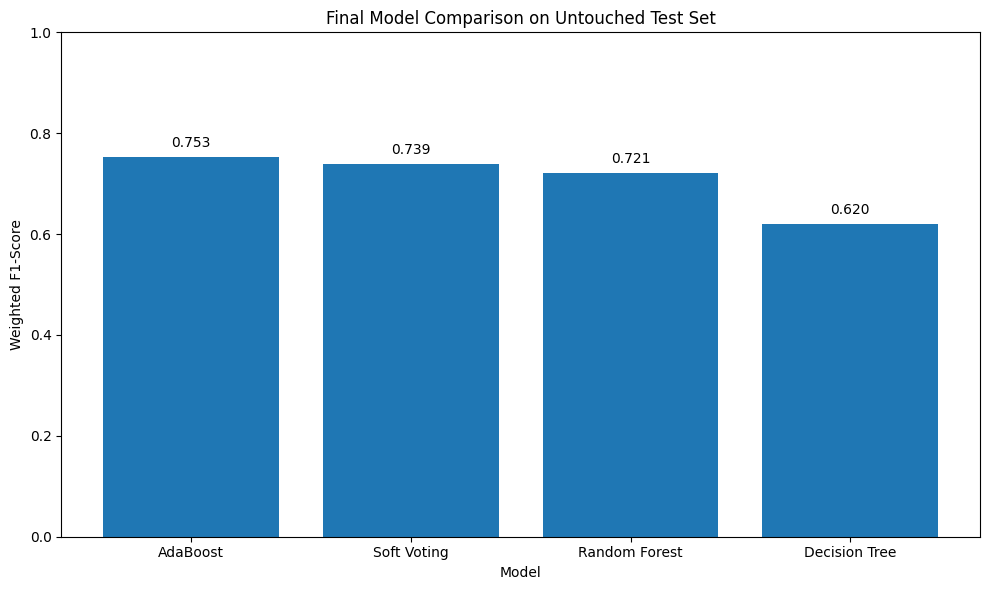


===== STEP 64 COMPLETED =====


In [80]:
# ============================================================
# STEP 64: FINAL MODEL COMPARISON VISUALIZATION
# ============================================================

print("\n===== STEP 64: FINAL MODEL COMPARISON VISUALIZATION =====")

import matplotlib.pyplot as plt

# Use final report results
plot_data = final_results_report.copy()

# Set model names and F1 scores
models_plot = plot_data["Model"]
f1_scores = plot_data["F1-Score"]

plt.figure(figsize=(10, 6))

plt.bar(
    models_plot,
    f1_scores
)

plt.ylabel("Weighted F1-Score")
plt.xlabel("Model")
plt.title("Final Model Comparison on Untouched Test Set")

plt.ylim(0, 1)

# Add values above bars
for i, value in enumerate(f1_scores):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\n===== STEP 64 COMPLETED =====")

Calculate the Improvement Over Baseline

In [81]:
# ============================================================
# STEP 65: FINAL IMPROVEMENT OVER BASELINE
# ============================================================

print("\n===== STEP 65: IMPROVEMENT OVER BASELINE =====")

baseline_accuracy = final_results_report.loc[
    final_results_report["Model"] == "Decision Tree",
    "Accuracy (%)"
].iloc[0]

adaboost_accuracy = final_results_report.loc[
    final_results_report["Model"] == "AdaBoost",
    "Accuracy (%)"
].iloc[0]

baseline_f1 = final_results_report.loc[
    final_results_report["Model"] == "Decision Tree",
    "F1-Score"
].iloc[0]

adaboost_f1 = final_results_report.loc[
    final_results_report["Model"] == "AdaBoost",
    "F1-Score"
].iloc[0]

accuracy_improvement = adaboost_accuracy - baseline_accuracy
f1_improvement = adaboost_f1 - baseline_f1

print("\n===== ACCURACY IMPROVEMENT =====")
print(f"Baseline Accuracy : {baseline_accuracy:.2f}%")
print(f"AdaBoost Accuracy : {adaboost_accuracy:.2f}%")
print(f"Improvement       : {accuracy_improvement:.2f} percentage points")

print("\n===== F1 IMPROVEMENT =====")
print(f"Baseline F1 : {baseline_f1:.4f}")
print(f"AdaBoost F1 : {adaboost_f1:.4f}")
print(f"Improvement : {f1_improvement:.4f}")

print("\n===== FINAL CONCLUSION =====")
print(
    f"AdaBoost improved test accuracy by "
    f"{accuracy_improvement:.2f} percentage points "
    f"over the Decision Tree baseline."
)

print("\n===== STEP 65 COMPLETED =====")


===== STEP 65: IMPROVEMENT OVER BASELINE =====

===== ACCURACY IMPROVEMENT =====
Baseline Accuracy : 62.41%
AdaBoost Accuracy : 75.35%
Improvement       : 12.94 percentage points

===== F1 IMPROVEMENT =====
Baseline F1 : 0.6202
AdaBoost F1 : 0.7532
Improvement : 0.1330

===== FINAL CONCLUSION =====
AdaBoost improved test accuracy by 12.94 percentage points over the Decision Tree baseline.

===== STEP 65 COMPLETED =====


Dataset Source Documentation

In [82]:
# ============================================================
# STEP 66: DATASET SOURCE DOCUMENTATION
# ============================================================

print("\n===== STEP 66: DATASET SOURCE DOCUMENTATION =====")

dataset_source = {
    "Dataset": "Air Quality Data in India (2015–2020)",
    "File Used": "city_day.csv",
    "Primary Dataset Publisher": "Rohan Rao / Kaggle",
    "Underlying Data Source": "Central Pollution Control Board (CPCB), Government of India",
    "Data Level": "Daily city-level air quality observations",
    "Domain": "Environment / Air Quality",
    "Time Period": "2015–2020",
    "Target": "AQI category",
    "Source URL": "https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india"
}

print("\n===== DATASET DETAILS =====")

for key, value in dataset_source.items():
    print(f"{key}: {value}")

print("\n===== DATASET JUSTIFICATION =====")

print(
    "The dataset is appropriate for the Earth/Environment mission "
    "because it contains daily air-quality measurements and AQI "
    "information across multiple Indian cities."
)

print(
    "The dataset is publicly available and its acknowledgement "
    "identifies the Central Pollution Control Board (CPCB) as "
    "the source of the underlying data."
)

print("\n===== STEP 66 COMPLETED =====")


===== STEP 66: DATASET SOURCE DOCUMENTATION =====

===== DATASET DETAILS =====
Dataset: Air Quality Data in India (2015–2020)
File Used: city_day.csv
Primary Dataset Publisher: Rohan Rao / Kaggle
Underlying Data Source: Central Pollution Control Board (CPCB), Government of India
Data Level: Daily city-level air quality observations
Domain: Environment / Air Quality
Time Period: 2015–2020
Target: AQI category
Source URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india

===== DATASET JUSTIFICATION =====
The dataset is appropriate for the Earth/Environment mission because it contains daily air-quality measurements and AQI information across multiple Indian cities.
The dataset is publicly available and its acknowledgement identifies the Central Pollution Control Board (CPCB) as the source of the underlying data.

===== STEP 66 COMPLETED =====


Real-World Impact Framing

In [83]:
# ============================================================
# STEP 67: REAL-WORLD IMPACT FRAMING
# ============================================================

print("\n===== STEP 67: REAL-WORLD IMPACT FRAMING =====")

print("\n===== MISSION DOMAIN =====")
print("Earth / Environment")

print("\n===== SOCIAL / ENVIRONMENTAL PROBLEM =====")
print(
    "Poor air quality can create environmental and public-health risks. "
    "The goal of this project is to classify daily air-quality conditions "
    "into AQI categories using pollutant measurements and contextual features."
)

print("\n===== INTENDED BENEFICIARIES =====")
print(
    "Potential beneficiaries include citizens, environmental monitoring "
    "teams, local authorities, researchers, and communities affected by "
    "poor air quality."
)

print("\n===== PREDICTION TARGET =====")
print(
    "AQI Category: Good, Moderate, Poor, Satisfactory, Severe, Very Poor"
)

print("\n===== UNIT OF ANALYSIS =====")
print(
    "One daily observation for a specific city."
)

print("\n===== WHY MACHINE LEARNING IS SUITABLE =====")
print(
    "Machine learning is suitable because air-quality categories depend "
    "on relationships among multiple pollutant measurements and temporal "
    "and geographic features. Ensemble models can capture nonlinear and "
    "complex relationships among these variables."
)

print("\n===== MEASURABLE IMPACT =====")
print(
    "The solution can provide an automated classification of air-quality "
    "conditions that can support early awareness, monitoring, and "
    "environmental decision-making."
)

print("\n===== RESPONSIBLE-USE LIMITATIONS =====")
print(
    "The model should be treated as a decision-support tool rather than "
    "a replacement for official air-quality monitoring or environmental "
    "health authorities."
)

print(
    "The model's performance varies across AQI categories, and false "
    "negatives can underestimate air-quality risk."
)

print(
    "The model should be externally validated on new and geographically "
    "representative data before any real-world deployment."
)

print("\n===== STEP 67 COMPLETED =====")


===== STEP 67: REAL-WORLD IMPACT FRAMING =====

===== MISSION DOMAIN =====
Earth / Environment

===== SOCIAL / ENVIRONMENTAL PROBLEM =====
Poor air quality can create environmental and public-health risks. The goal of this project is to classify daily air-quality conditions into AQI categories using pollutant measurements and contextual features.

===== INTENDED BENEFICIARIES =====
Potential beneficiaries include citizens, environmental monitoring teams, local authorities, researchers, and communities affected by poor air quality.

===== PREDICTION TARGET =====
AQI Category: Good, Moderate, Poor, Satisfactory, Severe, Very Poor

===== UNIT OF ANALYSIS =====
One daily observation for a specific city.

===== WHY MACHINE LEARNING IS SUITABLE =====
Machine learning is suitable because air-quality categories depend on relationships among multiple pollutant measurements and temporal and geographic features. Ensemble models can capture nonlinear and complex relationships among these variable

Final Pipeline Summary

In [84]:
# ============================================================
# STEP 68: FINAL END-TO-END PIPELINE SUMMARY
# ============================================================

print("\n===== STEP 68: FINAL END-TO-END PIPELINE SUMMARY =====")

pipeline_steps = [
    "1. Load public city-level air-quality dataset",
    "2. Audit data types, missing values, duplicates and invalid values",
    "3. Remove Xylene because of excessive missingness",
    "4. Split data into training, validation and untouched test sets",
    "5. Handle missing numerical values using training-set medians",
    "6. Engineer temporal features from Date",
    "7. Encode city information using one-hot encoding",
    "8. Scale numerical features",
    "9. Encode AQI categories",
    "10. Address class imbalance using class-weighted models",
    "11. Train Decision Tree baseline",
    "12. Train Random Forest bagging ensemble",
    "13. Train AdaBoost boosting ensemble",
    "14. Train heterogeneous Soft Voting ensemble",
    "15. Compare models using validation and cross-validation",
    "16. Evaluate all models on the untouched test set",
    "17. Select AdaBoost based on final test performance",
    "18. Generate confusion matrix and error analysis",
    "19. Perform global SHAP explainability",
    "20. Perform individual SHAP explainability",
    "21. Analyse prediction uncertainty using decision margins",
    "22. Perform responsible-use and ethics analysis",
    "23. Generate live prediction using a synthetic air-quality record"
]

print("\n===== COMPLETE ML PIPELINE =====")

for step in pipeline_steps:
    print(step)

print("\n===== FINAL MODEL =====")
print("AdaBoost")

print("\n===== FINAL TEST PERFORMANCE =====")
print("Accuracy : 75.35%")
print("Precision: 75.41%")
print("Recall   : 75.35%")
print("F1-Score : 0.7532")

print("\n===== STEP 68 COMPLETED =====")


===== STEP 68: FINAL END-TO-END PIPELINE SUMMARY =====

===== COMPLETE ML PIPELINE =====
1. Load public city-level air-quality dataset
2. Audit data types, missing values, duplicates and invalid values
3. Remove Xylene because of excessive missingness
4. Split data into training, validation and untouched test sets
5. Handle missing numerical values using training-set medians
6. Engineer temporal features from Date
7. Encode city information using one-hot encoding
8. Scale numerical features
9. Encode AQI categories
10. Address class imbalance using class-weighted models
11. Train Decision Tree baseline
12. Train Random Forest bagging ensemble
13. Train AdaBoost boosting ensemble
14. Train heterogeneous Soft Voting ensemble
15. Compare models using validation and cross-validation
16. Evaluate all models on the untouched test set
17. Select AdaBoost based on final test performance
18. Generate confusion matrix and error analysis
19. Perform global SHAP explainability
20. Perform individ

In [ ]:
# ============================================================
# LIVE PREDICTION INTERFACE
# ============================================================

print("\n===== LIVE AQI PREDICTION INTERFACE =====")

import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# City
# ------------------------------------------------------------

city_dropdown = widgets.Dropdown(
    options=[
        "Ahmedabad",
        "Amaravati",
        "Amritsar",
        "Bengaluru",
        "Brajrajnagar",
        "Chennai",
        "Delhi",
        "Gurugram",
        "Hyderabad",
        "Jaipur",
        "Jorapokhar",
        "Kolkata",
        "Lucknow",
        "Mumbai",
        "Patna",
        "Talcher",
        "Thiruvananthapuram",
        "Visakhapatnam"
    ],
    value="Ahmedabad",
    description="City:"
)

# ------------------------------------------------------------
# Pollutant inputs
# ------------------------------------------------------------

pm25_input = widgets.FloatText(
    value=85.0,
    description="PM2.5:"
)

pm10_input = widgets.FloatText(
    value=150.0,
    description="PM10:"
)

no_input = widgets.FloatText(
    value=25.0,
    description="NO:"
)

no2_input = widgets.FloatText(
    value=40.0,
    description="NO2:"
)

nox_input = widgets.FloatText(
    value=45.0,
    description="NOx:"
)

nh3_input = widgets.FloatText(
    value=25.0,
    description="NH3:"
)

co_input = widgets.FloatText(
    value=1.8,
    description="CO:"
)

so2_input = widgets.FloatText(
    value=15.0,
    description="SO2:"
)

o3_input = widgets.FloatText(
    value=35.0,
    description="O3:"
)

benzene_input = widgets.FloatText(
    value=2.0,
    description="Benzene:"
)

toluene_input = widgets.FloatText(
    value=5.0,
    description="Toluene:"
)

aqi_input = widgets.FloatText(
    value=180.0,
    description="AQI:"
)

# ------------------------------------------------------------
# Date inputs
# ------------------------------------------------------------

year_input = widgets.IntText(
    value=2020,
    description="Year:"
)

month_input = widgets.IntText(
    value=11,
    min=1,
    max=12,
    description="Month:"
)

day_input = widgets.IntText(
    value=15,
    min=1,
    max=31,
    description="Day:"
)

dayofweek_input = widgets.IntText(
    value=6,
    min=0,
    max=6,
    description="DayOfWeek:"
)

dayofyear_input = widgets.IntText(
    value=320,
    min=1,
    max=366,
    description="DayOfYear:"
)

isweekend_input = widgets.IntSlider(
    value=1,
    min=0,
    max=1,
    description="Weekend:"
)

# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

predict_button = widgets.Button(
    description="Predict AQI Category",
    button_style="success"
)

prediction_output = widgets.Output()


def make_prediction(button):

    with prediction_output:

        clear_output()

        try:

            # -----------------------------------------------
            # Create user input
            # -----------------------------------------------

            user_record = {
                "PM2.5": pm25_input.value,
                "PM10": pm10_input.value,
                "NO": no_input.value,
                "NO2": no2_input.value,
                "NOx": nox_input.value,
                "NH3": nh3_input.value,
                "CO": co_input.value,
                "SO2": so2_input.value,
                "O3": o3_input.value,
                "Benzene": benzene_input.value,
                "Toluene": toluene_input.value,
                "AQI": aqi_input.value,
                "Year": year_input.value,
                "Month": month_input.value,
                "Day": day_input.value,
                "DayOfWeek": dayofweek_input.value,
                "DayOfYear": dayofyear_input.value,
                "IsWeekend": isweekend_input.value
            }

            user_df = pd.DataFrame([user_record])

            # -----------------------------------------------
            # Scale numerical features
            # -----------------------------------------------

            user_processed = user_df.copy()

            user_processed[numeric_features] = scaler.transform(
                user_df[numeric_features]
            )

            # -----------------------------------------------
            # Add city one-hot features
            # -----------------------------------------------

            city_columns = [
                col
                for col in X_train_scaled.columns
                if col.startswith("City_")
            ]

            for column in city_columns:
                user_processed[column] = 0

            selected_city_column = "City_" + city_dropdown.value

            if selected_city_column in user_processed.columns:
                user_processed[selected_city_column] = 1

            # -----------------------------------------------
            # Align features EXACTLY with training data
            # -----------------------------------------------

            user_processed = user_processed.reindex(
                columns=X_train_scaled.columns,
                fill_value=0
            )

            # -----------------------------------------------
            # Prediction
            # -----------------------------------------------

            prediction = final_model.predict(
                user_processed
            )[0]

            predicted_category = target_names[
                int(prediction)
            ]

            # -----------------------------------------------
            # Decision scores
            # -----------------------------------------------

            scores = final_model.decision_function(
                user_processed
            )[0]

            sorted_scores = np.sort(scores)

            margin = (
                sorted_scores[-1] -
                sorted_scores[-2]
            )

            # -----------------------------------------------
            # Display result
            # -----------------------------------------------

            print("========================================")
            print("       LIVE AQI PREDICTION")
            print("========================================")

            print("\nCity:", city_dropdown.value)

            print(
                "\nPredicted AQI Category:",
                predicted_category
            )

            print(
                "\nDecision Margin:",
                round(float(margin), 6)
            )

            print(
                "\nModel:",
                "AdaBoost"
            )

            print(
                "Test Accuracy:",
                "75.35%"
            )

            print("\n========================================")

        except Exception as error:

            print("Prediction error:")
            print(error)


predict_button.on_click(make_prediction)

# ------------------------------------------------------------
# Display interface
# ------------------------------------------------------------

display(
    city_dropdown,
    pm25_input,
    pm10_input,
    no_input,
    no2_input,
    nox_input,
    nh3_input,
    co_input,
    so2_input,
    o3_input,
    benzene_input,
    toluene_input,
    aqi_input,
    year_input,
    month_input,
    day_input,
    dayofweek_input,
    dayofyear_input,
    isweekend_input,
    predict_button,
    prediction_output
)


===== LIVE AQI PREDICTION INTERFACE =====


Dropdown(description='City:', options=('Ahmedabad', 'Amaravati', 'Amritsar', 'Bengaluru', 'Brajrajnagar', 'Che…

FloatText(value=85.0, description='PM2.5:')

FloatText(value=150.0, description='PM10:')

FloatText(value=25.0, description='NO:')

...

IntText(value=6, description='DayOfWeek:')

IntText(value=320, description='DayOfYear:')

IntSlider(value=1, description='Weekend:', max=1)

Button(button_style='success', description='Predict AQI Category', style=ButtonStyle())

Output()